In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
file_path = "Bean there done that data.xlsx"

In [3]:
df_sales = pd.read_excel(file_path, sheet_name="E-com sales orders by product")[["Product", "Bag type", "Quantity", "Order date"]]
df_b2b = pd.read_excel(file_path, sheet_name="B2B orders")[["Product", "Bag type", "Quantity", "Delivery date"]]

In [28]:
df_sales = df_sales.rename(columns={"Order date": "Date"})
df_b2b = df_b2b.rename(columns={"Delivery date": "Date"})
df_all = pd.concat([df_sales, df_b2b], ignore_index=True)

In [29]:
df_all["Date"] = pd.to_datetime(df_all["Date"])
df_all["Month"] = df_all["Date"].dt.to_period("M")

In [30]:
df_all["KG"] = df_all.apply(lambda row: row["Quantity"] * (0.5 if row["Bag type"] == 1 else 1.0), axis=1)

In [31]:
monthly_roast = df_all.groupby(["Month", "Product"])["KG"].sum().reset_index()
monthly_roast["Month"] = monthly_roast["Month"].dt.to_timestamp()

In [32]:
df_inventory = pd.read_excel(file_path, sheet_name="Inventory (finished product)")
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
df_inventory["Month"] = pd.Categorical(df_inventory["Month"], categories=month_order, ordered=True)
monthly_inventory = df_inventory.groupby(["Month", "Product"])["Stock level"].sum().reset_index()

C:\Users\matej\AppData\Local\Temp\ipykernel_8836\1583520440.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_inventory = df_inventory.groupby(["Month", "Product"])["Stock level"].sum().reset_index()


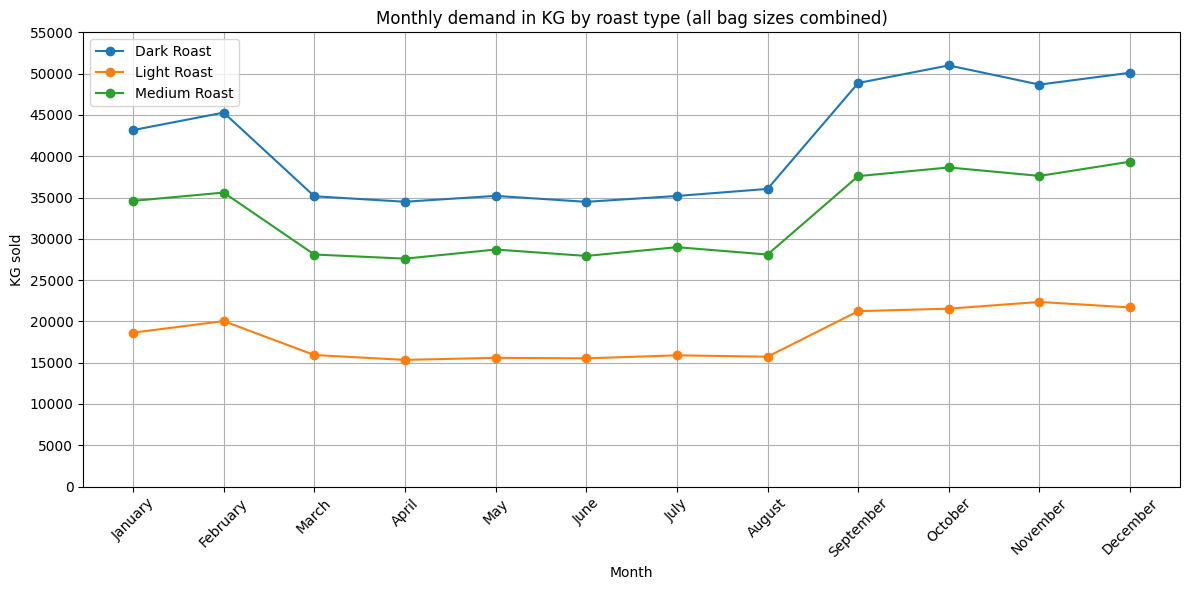

In [35]:
max_demand = monthly_roast["KG"].max()
y_max = (int(np.ceil(max_demand / 5000.0)) * 5000)

# vytvoříme nový sloupec s názvem měsíce
monthly_roast["Month_name"] = monthly_roast["Month"].dt.month_name()

# Demand graf s názvy měsíců
plt.figure(figsize=(12,6))
for product in monthly_roast["Product"].unique():
    product_data = monthly_roast[monthly_roast["Product"] == product]
    plt.plot(product_data["Month_name"], product_data["KG"], marker="o", linestyle="-", label=product)

plt.title("Monthly demand in KG by roast type (all bag sizes combined)")
plt.xlabel("Month")
plt.ylabel("KG sold")
plt.legend()

plt.xticks(rotation=45)
plt.ylim(0, y_max)
plt.yticks(np.arange(0, y_max+1, 5000))

plt.grid(True)
plt.tight_layout()
plt.show()


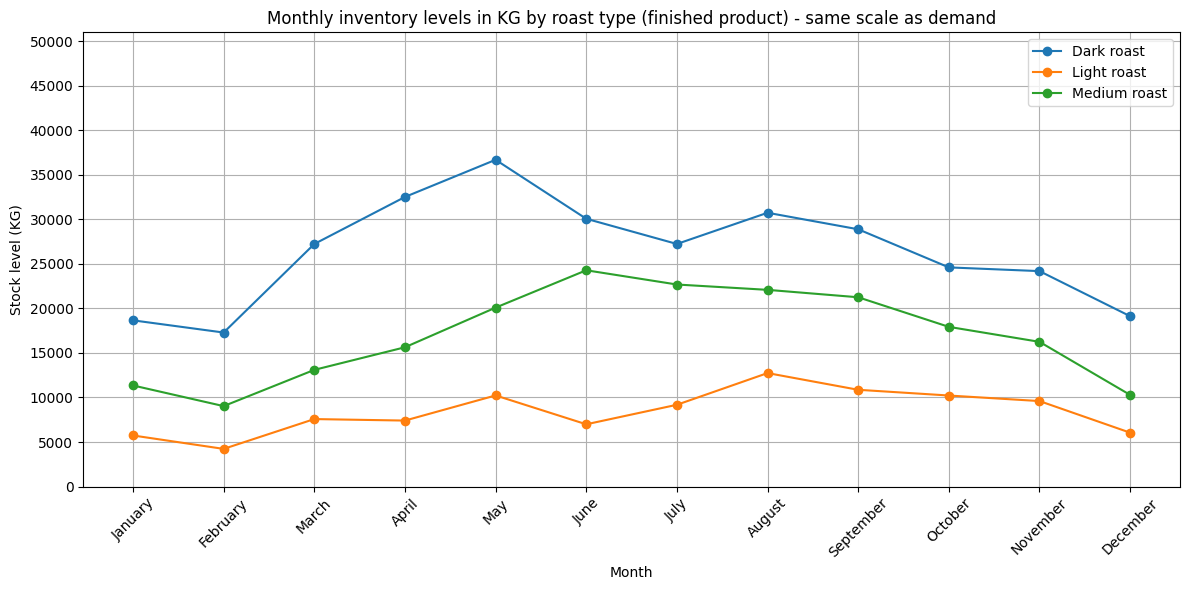

In [36]:
max_demand = monthly_roast["KG"].max()
y_max = (int(np.ceil(max_demand / 5000.0)) * 5000)
plt.figure(figsize=(12,6))
for product in monthly_inventory["Product"].unique():
    product_data = monthly_inventory[monthly_inventory["Product"] == product]
    plt.plot(product_data["Month"], product_data["Stock level"], marker="o", linestyle="-", label=product)
plt.title("Monthly inventory levels in KG by roast type (finished product) - same scale as demand")
plt.xlabel("Month")
plt.ylabel("Stock level (KG)")
plt.legend()
plt.xticks(rotation=45)
plt.ylim(0, max_demand)  # nastavení stejné osy Y jako u demand
plt.yticks(np.arange(0, y_max, 5000))
plt.grid(True)
plt.tight_layout()
plt.show()

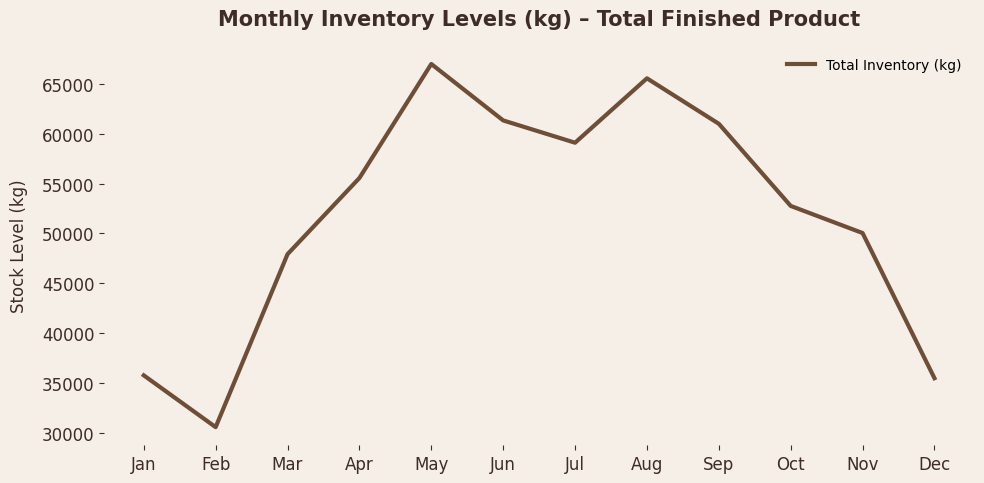

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1️⃣ Load dataset ===
file_path = "Bean there done that data.xlsx"
inv_fp = pd.read_excel(file_path, sheet_name="Inventory (finished product)")

# === 2️⃣ Clean column names ===
inv_fp.columns = inv_fp.columns.str.strip().str.lower().str.replace(" ", "_")

# === 3️⃣ Aggregate total stock by month ===
monthly_total = inv_fp.groupby("month", as_index=False)["stock_level"].sum()

# === 4️⃣ Define order and abbreviations for months ===
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
month_abbr = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# Apply correct order
monthly_total["month"] = pd.Categorical(monthly_total["month"], categories=month_order, ordered=True)
monthly_total = monthly_total.sort_values("month").reset_index(drop=True)

# Replace with abbreviations
monthly_total["month_abbr"] = month_abbr

# === 5️⃣ Coffee color palette ===
colors = {
    "line": "#6F4E37",    # espresso brown
    "bg": "#F5EFE7",      # warm beige
    "text": "#3E2C26"     # dark chocolate
}

# === 6️⃣ Global style settings ===
plt.style.use("default")
plt.rcParams.update({
    "axes.facecolor": colors["bg"],
    "figure.facecolor": colors["bg"],
    "axes.edgecolor": "none",
    "axes.labelcolor": colors["text"],
    "xtick.color": colors["text"],
    "ytick.color": colors["text"],
    "font.family": "sans-serif",
    "font.size": 12
})

# === 7️⃣ Plot ===
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    monthly_total["month_abbr"],
    monthly_total["stock_level"],
    color=colors["line"],
    linewidth=3,
    label="Total Inventory (kg)"
)

# === 8️⃣ Clean up chart ===
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

ax.set_title("Monthly Inventory Levels (kg) – Total Finished Product",
             fontsize=15, fontweight="bold", color=colors["text"], pad=15)
ax.set_xlabel("")
ax.set_ylabel("Stock Level (kg)", fontsize=12, labelpad=10)
ax.legend(frameon=False, fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()


In [37]:
df_ecom = pd.read_excel(file_path, sheet_name="E-com sales orders by product")
df_inv = pd.read_excel(file_path, sheet_name="Inventory (finished product)")
df_b2b = pd.read_excel(file_path, sheet_name="B2B orders")

In [38]:
# --- E-commerce poptávka ---
df_ecom['Order date'] = pd.to_datetime(df_ecom['Order date'])
df_ecom['Month'] = df_ecom['Order date'].dt.strftime('%B')
df_ecom['Product'] = df_ecom['Product'].str.lower()
df_ecom['Weight_kg'] = df_ecom['Quantity'] * df_ecom['Bag type'].map({1: 0.5, 2: 1})

demand_ecom = (
    df_ecom.groupby(['Product','Month'])['Weight_kg']
    .sum()
    .reset_index()
)

# --- B2B poptávka ---
df_b2b['Delivery date'] = pd.to_datetime(df_b2b['Delivery date'])
df_b2b['Month'] = df_b2b['Delivery date'].dt.strftime('%B')
df_b2b['Product'] = df_b2b['Product'].str.lower()
df_b2b['Weight_kg'] = df_b2b['Quantity'] * df_b2b['Bag type'].map({1: 0.5, 2: 1})

demand_b2b = (
    df_b2b.groupby(['Product','Month'])['Weight_kg']
    .sum()
    .reset_index()
)

# --- Sloučení obou poptávek ---
demand_total = pd.concat([demand_ecom, demand_b2b]) \
    .groupby(['Product','Month'])['Weight_kg'] \
    .sum().reset_index() \
    .rename(columns={'Weight_kg':'Demand (kg)'})

# --- Nabídka ---
df_inv['Product'] = df_inv['Product'].str.lower()
supply = df_inv[['Product','Month','Stock level']] \
    .rename(columns={'Stock level':'Supply (kg)'})

# --- Porovnání nabídky a poptávky ---
df_compare = pd.merge(supply, demand_total, on=['Product','Month'], how='left')
df_compare['Demand (kg)'] = df_compare['Demand (kg)'].fillna(0)

df_compare['Difference (kg)'] = df_compare['Supply (kg)'] - df_compare['Demand (kg)']
df_compare['Difference (kg)'] = df_compare['Difference (kg)'].apply(
    lambda x: f"+{x}" if x > 0 else f"{x}"
)

# --- Tabulky ---
light_table = df_compare[df_compare['Product'].str.contains('light')].drop(columns=['Product'])
medium_table = df_compare[df_compare['Product'].str.contains('medium')].drop(columns=['Product'])
dark_table = df_compare[df_compare['Product'].str.contains('dark')].drop(columns=['Product'])

print("Light Roast")
display(light_table)

print("Medium Roast")
display(medium_table)

print("Dark Roast")
display(dark_table)


Light Roast


,Month,Supply (kg),Demand (kg),Difference (kg)
24,January,5734,18635.0,-12901.0
25,February,4228,20036.0,-15808.0
26,March,7576,15927.0,-8351.0
27,April,7407,15337.5,-7930.5
28,May,10229,15587.0,-5358.0
29,June,6990,15523.5,-8533.5
30,July,9181,15888.5,-6707.5
31,August,12740,15723.5,-2983.5
32,September,10863,21236.5,-10373.5
33,October,10220,21542.0,-11322.0


Medium Roast


,Month,Supply (kg),Demand (kg),Difference (kg)
12,January,11349,34591.5,-23242.5
13,February,9030,35597.0,-26567.0
14,March,13100,28097.0,-14997.0
15,April,15637,27596.0,-11959.0
16,May,20087,28700.0,-8613.0
17,June,24281,27925.0,-3644.0
18,July,22682,28984.0,-6302.0
19,August,22083,28093.5,-6010.5
20,September,21251,37590.5,-16339.5
21,October,17928,38638.5,-20710.5


Dark Roast


,Month,Supply (kg),Demand (kg),Difference (kg)
0,January,18660,43161.5,-24501.5
1,February,17290,45281.0,-27991.0
2,March,27231,35151.0,-7920.0
3,April,32511,34485.5,-1974.5
4,May,36683,35197.0,+1486.0
5,June,30063,34475.5,-4412.5
6,July,27233,35184.0,-7951.0
7,August,30737,36041.0,-5304.0
8,September,28883,48865.0,-19982.0
9,October,24604,50993.0,-26389.0


In [39]:
df_roasting = pd.read_excel(file_path, sheet_name="Roasting")

In [40]:
df_roasting["Production_kg"] = df_roasting["Number of batches per day"] * df_roasting["Workdays"] * df_roasting["Final weight /pbatch"]

In [41]:
monthly_machine_roast = (
    df_roasting.groupby(["Month", "Machine", "Product type"])["Production_kg"]
    .sum()
    .reset_index()
)

In [42]:
pivot_df = monthly_machine_roast.pivot_table(
    index="Month",
    columns=["Machine", "Product type"],
    values="Production_kg",
    fill_value=0
)

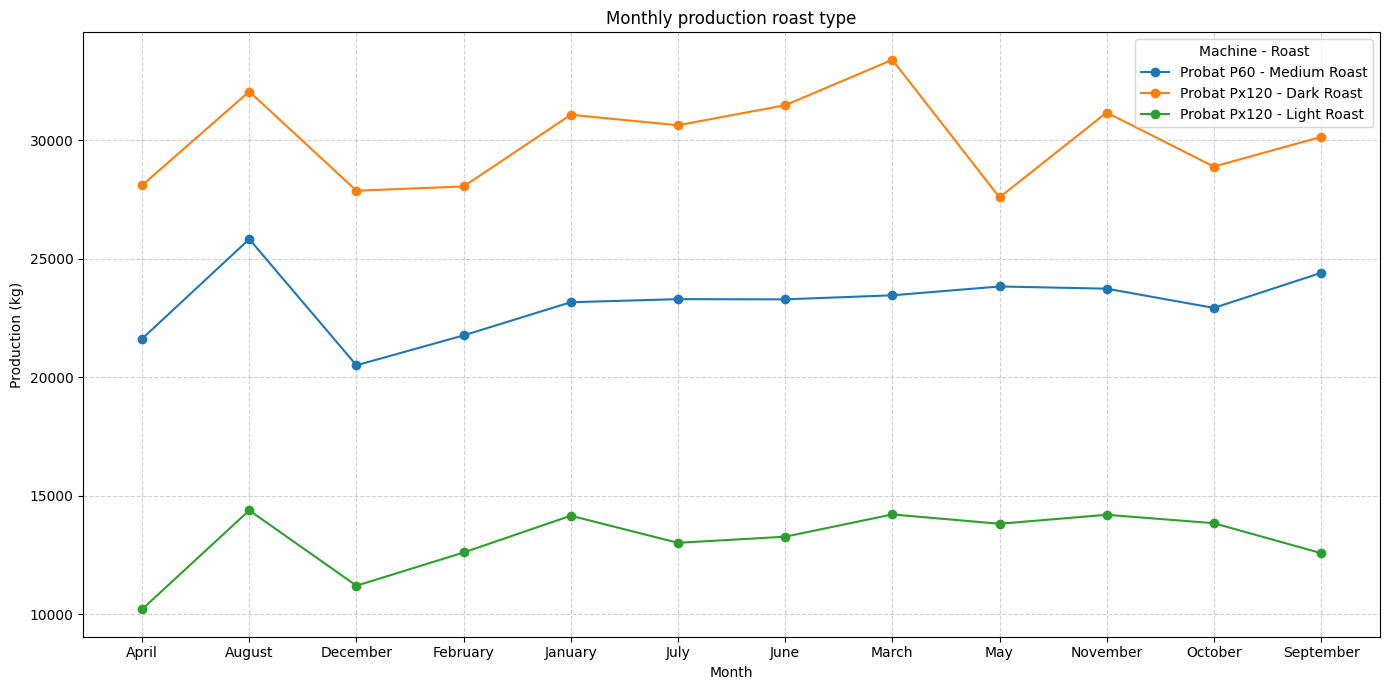

In [43]:
plt.figure(figsize=(14, 7))
for col in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[col], marker="o", label=f"{col[0]} - {col[1]}")

plt.title("Monthly production roast type")
plt.xlabel("Month")
plt.ylabel("Production (kg)")
plt.legend(title="Machine - Roast")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

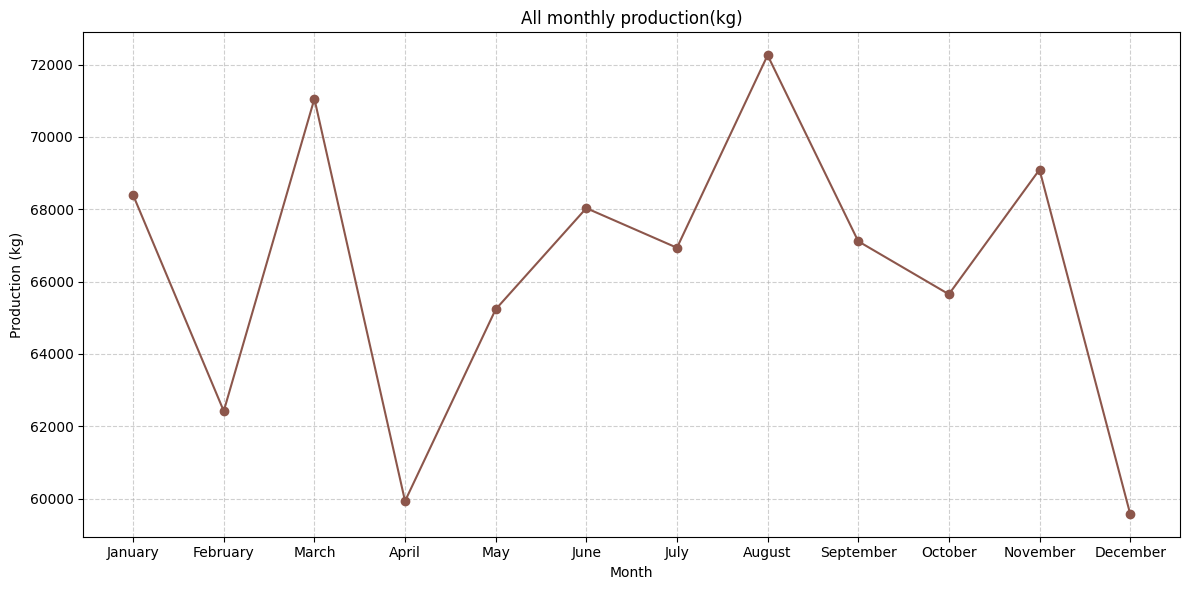

In [44]:
# Agregace celkové měsíční produkce (bez rozlišení strojů a roastu)
monthly_total = (
    df_roasting.groupby("Month")["Production_kg"]
    .sum()
    .reindex([
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ])
)

# Vykreslení line chartu
plt.figure(figsize=(12, 6))
plt.plot(monthly_total.index, monthly_total.values, marker="o", color="tab:brown")

plt.title("All monthly production(kg)")
plt.xlabel("Month")
plt.ylabel("Production (kg)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


KeyError: 'Actual production (kg)'

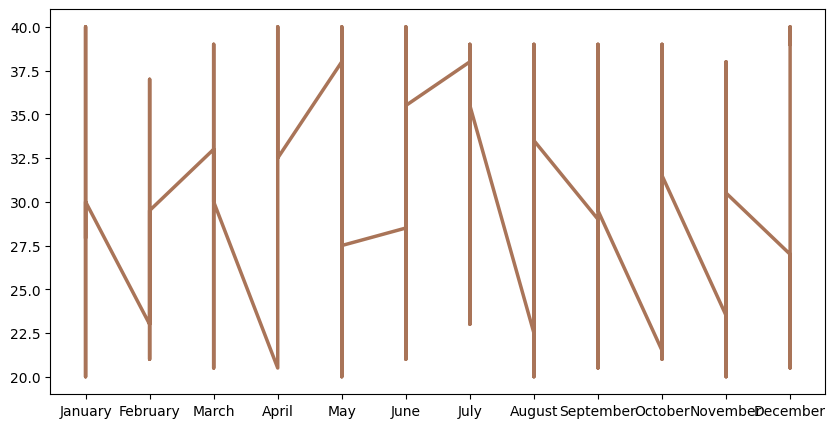

In [45]:
import matplotlib.pyplot as plt

# === Clean coffee-inspired color palette ===
colors = {
    "Demand": "#A97458",        # warm caramel
    "Production": "#6F4E37"     # espresso brown
}

plt.figure(figsize=(10, 5))

# === Line chart ===
plt.plot(df["Month"], df["Demand (kg)"], 
         label="Customer Demand", 
         color=colors["Demand"], 
         linestyle="-", linewidth=2.5)

plt.plot(df["Month"], df["Actual production (kg)"], 
         label="Actual Production", 
         color=colors["Production"], 
         linestyle="--", linewidth=2.5)

# === Style for presentation ===
plt.title("Monthly Demand vs. Actual Production (kg)", fontsize=14, weight="bold", pad=15)
plt.ylabel("Kilograms", fontsize=12)
plt.grid(True, color="#E6E6E6", linestyle="--", linewidth=0.7)

# Remove all spines and frames
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Clean ticks and legend
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.box(False)
plt.legend(frameon=False, fontsize=10, loc="upper left")

plt.tight_layout()
plt.show()


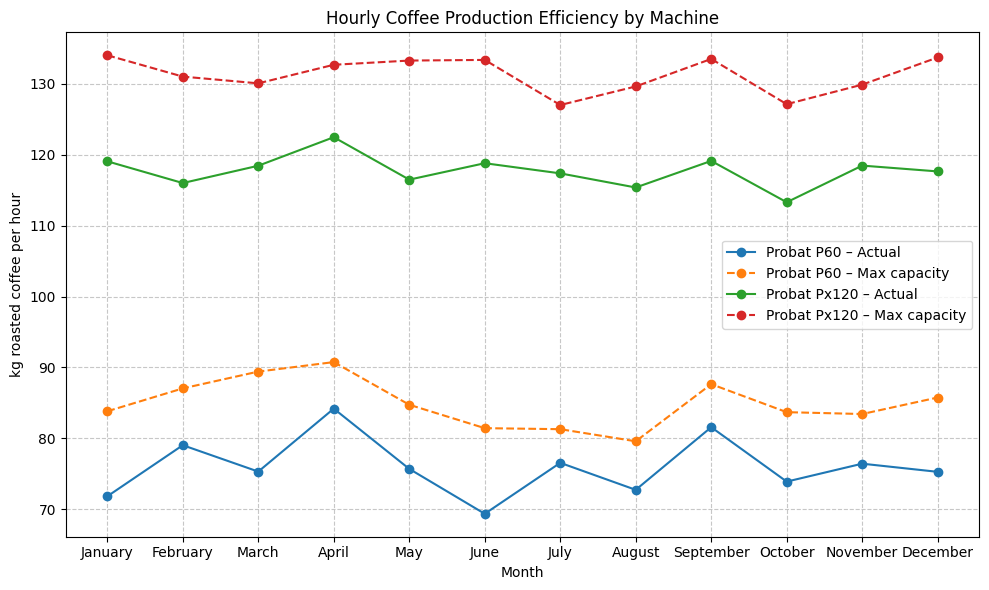

=== Average Machine Utilization Summary ===
        Machine  Actual_kg_per_hour  Max_kg_per_hour  Utilization_%  \
0    Probat P60               75.99            84.89          89.53   
1  Probat Px120              117.71           131.27          89.53   

   Efficiency gap (%)  
0               10.47  
1               10.47  


In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Load data
file_path = "Bean there done that data.xlsx"
roasting = pd.read_excel(file_path, sheet_name="Roasting")

# 2️⃣ Compute total process time per batch (in hours)
roasting["Total time per batch (min)"] = (
    roasting["Setup time p/batch"]
    + roasting["Run time p/batch (m)"]
    + roasting["Cooling time p/batch"]
    + roasting["Packing time p/batch"]
)
roasting["Total time per batch (h)"] = roasting["Total time per batch (min)"] / 60

# 3️⃣ Define maximum roasted coffee per batch (kg after roasting)
max_capacity = {"Probat P60": 51, "Probat Px120": 102}
roasting["Max weight /pbatch"] = roasting["Machine"].map(max_capacity)

# 4️⃣ Calculate actual and theoretical hourly production
roasting["Actual_kg_per_hour"] = roasting["Final weight /pbatch"] / roasting["Total time per batch (h)"]
roasting["Max_kg_per_hour"] = roasting["Max weight /pbatch"] / roasting["Total time per batch (h)"]
roasting["Utilization_%"] = (roasting["Actual_kg_per_hour"] / roasting["Max_kg_per_hour"]) * 100

# 5️⃣ Aggregate per month and machine
hourly_summary = (
    roasting.groupby(["Month", "Machine"])[["Actual_kg_per_hour", "Max_kg_per_hour", "Utilization_%"]]
    .mean()
    .reset_index()
)

# Sort months correctly
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
hourly_summary["Month"] = pd.Categorical(hourly_summary["Month"], categories=month_order, ordered=True)
hourly_summary = hourly_summary.sort_values("Month")

# 6️⃣ Visualization – Line chart: Actual vs Max production per hour
plt.figure(figsize=(10,6))
for machine in hourly_summary["Machine"].unique():
    machine_data = hourly_summary[hourly_summary["Machine"] == machine]
    plt.plot(
        machine_data["Month"], 
        machine_data["Actual_kg_per_hour"], 
        marker="o", linestyle="-", label=f"{machine} – Actual"
    )
    plt.plot(
        machine_data["Month"], 
        machine_data["Max_kg_per_hour"], 
        marker="o", linestyle="--", label=f"{machine} – Max capacity"
    )

plt.title("Hourly Coffee Production Efficiency by Machine")
plt.xlabel("Month")
plt.ylabel("kg roasted coffee per hour")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 7️⃣ Summary table – average utilization per machine
utilization_summary = (
    roasting.groupby("Machine")[["Actual_kg_per_hour", "Max_kg_per_hour", "Utilization_%"]]
    .mean()
    .reset_index()
)
utilization_summary["Efficiency gap (%)"] = 100 - utilization_summary["Utilization_%"]

print("=== Average Machine Utilization Summary ===")
print(utilization_summary.round(2))


=== Average Machine Working Hours per Day ===
        Month       Machine  Hours per day (calculated)
8     January    Probat P60                        4.90
9     January  Probat Px120                        2.14
6    February    Probat P60                        5.06
7    February  Probat Px120                        2.12
15      March  Probat Px120                        2.16
14      March    Probat P60                        4.74
0       April    Probat P60                        5.59
1       April  Probat Px120                        2.22
17        May  Probat Px120                        2.05
16        May    Probat P60                        5.28
13       June  Probat Px120                        2.12
12       June    Probat P60                        4.92
11       July  Probat Px120                        2.16
10       July    Probat P60                        5.16
3      August  Probat Px120                        2.10
2      August    Probat P60                        5.22
22

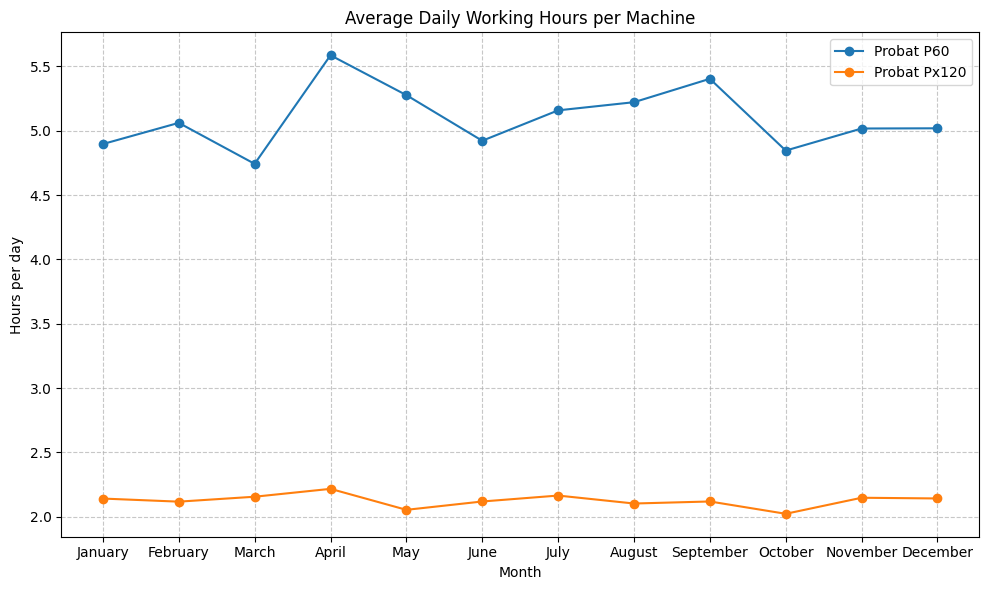

In [47]:
import pandas as pd

# Load dataset
file_path = "Bean there done that data.xlsx"
roasting = pd.read_excel(file_path, sheet_name="Roasting")

# Define machine max hourly capacity (from image)
machine_capacity = {
    'Probat P60': 215,   # kg/h
    'Probat Px120': 480  # kg/h
}

# Calculate daily production (kg)
roasting["Daily production (kg)"] = roasting["Final weight /pbatch"] * roasting["Number of batches per day"]

# Calculate daily working hours based on capacity
roasting["Machine capacity (kg/h)"] = roasting["Machine"].map(machine_capacity)
roasting["Hours per day (calculated)"] = roasting["Daily production (kg)"] / roasting["Machine capacity (kg/h)"]

# Average hours per machine and month
hours_summary = roasting.groupby(["Month", "Machine"])["Hours per day (calculated)"].mean().reset_index()

# Sort months
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
hours_summary["Month"] = pd.Categorical(hours_summary["Month"], categories=month_order, ordered=True)
hours_summary = hours_summary.sort_values("Month")

# Display table
print("=== Average Machine Working Hours per Day ===")
print(hours_summary.round(2))

# Optional: visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for machine in hours_summary["Machine"].unique():
    data = hours_summary[hours_summary["Machine"] == machine]
    plt.plot(data["Month"], data["Hours per day (calculated)"], marker="o", label=machine)

plt.title("Average Daily Working Hours per Machine")
plt.xlabel("Month")
plt.ylabel("Hours per day")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


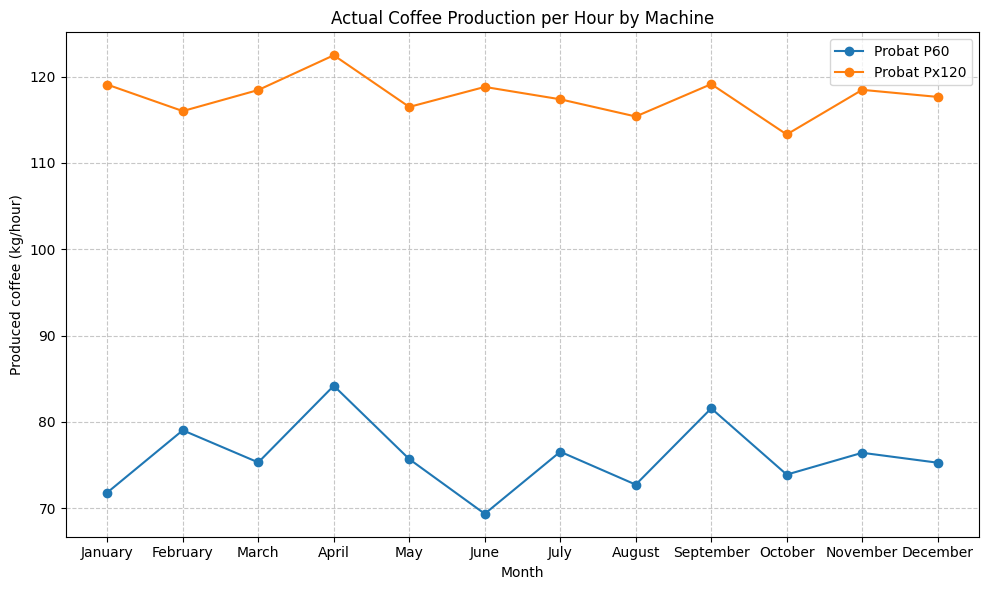

=== Average Hourly Production per Machine ===
        Machine  Average kg/h
0    Probat P60         75.99
1  Probat Px120        117.71


In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Load dataset
file_path = "Bean there done that data.xlsx"
roasting = pd.read_excel(file_path, sheet_name="Roasting")

# 2️⃣ Calculate total time per batch (in hours)
roasting["Total time per batch (h)"] = (
    roasting["Setup time p/batch"] +
    roasting["Run time p/batch (m)"] +
    roasting["Cooling time p/batch"] +
    roasting["Packing time p/batch"]
) / 60

# 3️⃣ Actual hourly production per batch
roasting["Actual_kg_per_hour"] = roasting["Final weight /pbatch"] / roasting["Total time per batch (h)"]

# 4️⃣ Aggregate by machine and month
hourly_machine = (
    roasting.groupby(["Month", "Machine"])["Actual_kg_per_hour"]
    .mean()
    .reset_index()
)

# Sort months chronologically
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
hourly_machine["Month"] = pd.Categorical(hourly_machine["Month"], categories=month_order, ordered=True)
hourly_machine = hourly_machine.sort_values("Month")

# 5️⃣ Visualization
plt.figure(figsize=(10,6))
for machine in hourly_machine["Machine"].unique():
    machine_data = hourly_machine[hourly_machine["Machine"] == machine]
    plt.plot(machine_data["Month"], machine_data["Actual_kg_per_hour"],
             marker="o", label=f"{machine}")

plt.title("Actual Coffee Production per Hour by Machine")
plt.xlabel("Month")
plt.ylabel("Produced coffee (kg/hour)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 6️⃣ Average performance per machine
average_hourly = (
    roasting.groupby("Machine")["Actual_kg_per_hour"]
    .mean()
    .reset_index()
    .rename(columns={"Actual_kg_per_hour": "Average kg/h"})
)
print("=== Average Hourly Production per Machine ===")
print(average_hourly.round(2))


In [50]:
import pandas as pd

# 1️⃣ Načteme data
file_path = "Bean there done that data.xlsx"
roasting = pd.read_excel(file_path, sheet_name="Roasting")

# 2️⃣ Spočítáme celkový čas na jednu várku (v minutách)
roasting["Total time per batch (min)"] = (
    roasting["Setup time p/batch"] +
    roasting["Run time p/batch (m)"] +
    roasting["Cooling time p/batch"] +
    roasting["Packing time p/batch"]
)

# 3️⃣ Průměrný čas podle stroje
avg_time_machine = (
    roasting.groupby("Machine")["Total time per batch (min)"]
    .mean()
    .reset_index()
    .rename(columns={"Total time per batch (min)": "Average time per batch (min)"})
)

# 4️⃣ Přehledně zobrazíme
print("=== Average Preparation Time per Batch by Machine ===")
print(avg_time_machine.round(2))

# 5️⃣ (volitelné) – podle typu pražení
avg_time_roast = (
    roasting.groupby("Product type")["Total time per batch (min)"]
    .mean()
    .reset_index()
    .rename(columns={"Total time per batch (min)": "Average time per batch (min)"})
)

print("\n=== Average Preparation Time per Batch by Roast Type ===")
print(avg_time_roast.round(2))


=== Average Preparation Time per Batch by Machine ===
        Machine  Average time per batch (min)
0    Probat P60                         36.10
1  Probat Px120                         46.78

=== Average Preparation Time per Batch by Roast Type ===
   Product type  Average time per batch (min)
0    Dark Roast                         49.24
1   Light Roast                         44.31
2  Medium Roast                         36.10


In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = "Bean there done that data.xlsx"

# Display all sheet names to locate the relevant data
excel_file = pd.ExcelFile(file_path)
excel_file.sheet_names


['Inventory (raw material)',
 'Inventory (finished product)',
 'Roasting',
 'E-com sales orders by product',
 'B2B orders']

In [52]:
# Load the "Roasting" sheet where production details are likely stored
roasting_df = pd.read_excel(file_path, sheet_name="Roasting")

# Display first few rows to inspect structure
roasting_df.head()


,Machine,Month,Product type,Workdays,Number of batches per day,Load weight p/batch,Final weight /pbatch,Setup time p/batch,Run time p/batch (m),Cooling time p/batch,Packing time p/batch,QC fail/ Weight,QC fail/ Color,QC fail/ Roast profile,Total rejected batches p/month
0,Probat P60,January,Medium Roast,22,24.090909,53.346030,43.702650,4.120657,15.812592,9.275969,7.296741,3,4,0,7
1,Probat Px120,January,Dark Roast,22,16.363636,109.066520,86.292139,5.968155,16.627882,10.822810,15.449934,3,0,1,4
2,Probat Px120,January,Light Roast,22,6.818182,110.087409,94.413660,4.885796,14.977055,9.327127,13.664163,2,0,2,4
3,Probat P60,February,Medium Roast,20,23.500000,56.378035,46.307461,3.711352,15.786107,9.302263,6.353634,0,2,3,5
4,Probat Px120,February,Dark Roast,20,16.150000,108.435025,86.819715,5.838287,17.537513,10.238845,16.019197,1,0,0,1


In [53]:
# Convert times from minutes to hours for total batch time
roasting_df["Total time (h)"] = (
    roasting_df["Setup time p/batch"] +
    roasting_df["Run time p/batch (m)"] +
    roasting_df["Cooling time p/batch"]
) / 60

# Actual monthly production
roasting_df["Actual production (kg)"] = (
    roasting_df["Final weight /pbatch"] *
    roasting_df["Number of batches per day"] *
    roasting_df["Workdays"]
)

# Maximum theoretical monthly production based on max batch size and time
hours_per_month = 16 * 22
roasting_df["Max capacity (kg)"] = (
    (roasting_df["Load weight p/batch"] / roasting_df["Total time (h)"]) *
    hours_per_month
)

# Utilization rate
roasting_df["Utilization (%)"] = (roasting_df["Actual production (kg)"] /
                                  roasting_df["Max capacity (kg)"]) * 100

# Group by product type and month to aggregate results
monthly_summary = roasting_df.groupby(["Month", "Product type"], as_index=False)[
    ["Actual production (kg)", "Max capacity (kg)", "Utilization (%)"]
].mean()

# Preview the results
monthly_summary.head()


,Month,Product type,Actual production (kg),Max capacity (kg),Utilization (%)
0,April,Dark Roast,28088.811554,70463.440352,39.862958
1,April,Light Roast,10218.837448,72279.629362,14.137922
2,April,Medium Roast,21621.400281,43388.454376,49.832151
3,August,Dark Roast,32045.716674,72364.398769,44.283815
4,August,Light Roast,14386.691496,70080.361801,20.528849


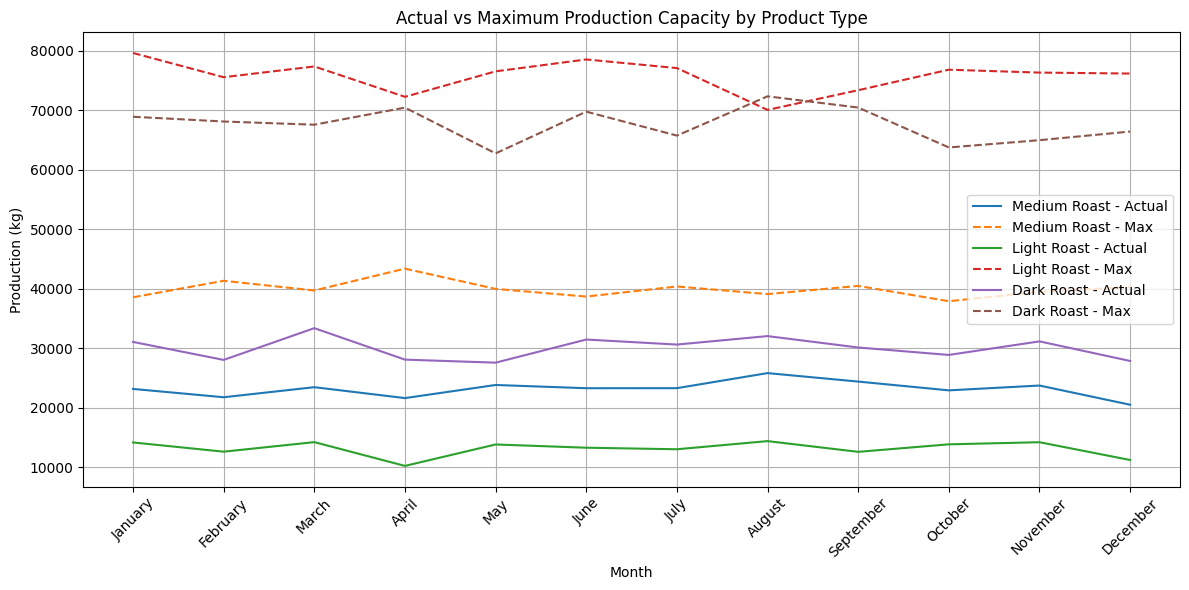

,Product type,Actual production (kg),Max capacity (kg),Utilization (%)
0,Dark Roast,30027.437334,67622.176409,44.440740
1,Light Roast,13129.774839,75832.928508,17.318383
2,Medium Roast,23148.721255,39948.546864,58.062201


In [54]:
# Sort months in correct calendar order for line plotting
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
monthly_summary["Month"] = pd.Categorical(monthly_summary["Month"], categories=month_order, ordered=True)
monthly_summary = monthly_summary.sort_values("Month")

# Plot: Actual vs Max Capacity over time by Product Type
plt.figure(figsize=(12, 6))
for roast in monthly_summary["Product type"].unique():
    subset = monthly_summary[monthly_summary["Product type"] == roast]
    plt.plot(subset["Month"], subset["Actual production (kg)"], label=f"{roast} - Actual", linestyle='-')
    plt.plot(subset["Month"], subset["Max capacity (kg)"], label=f"{roast} - Max", linestyle='--')

plt.title("Actual vs Maximum Production Capacity by Product Type")
plt.xlabel("Month")
plt.ylabel("Production (kg)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Table: Average utilization by product type
utilization_summary = roasting_df.groupby("Product type")[["Actual production (kg)", "Max capacity (kg)", "Utilization (%)"]].mean().reset_index()
utilization_summary


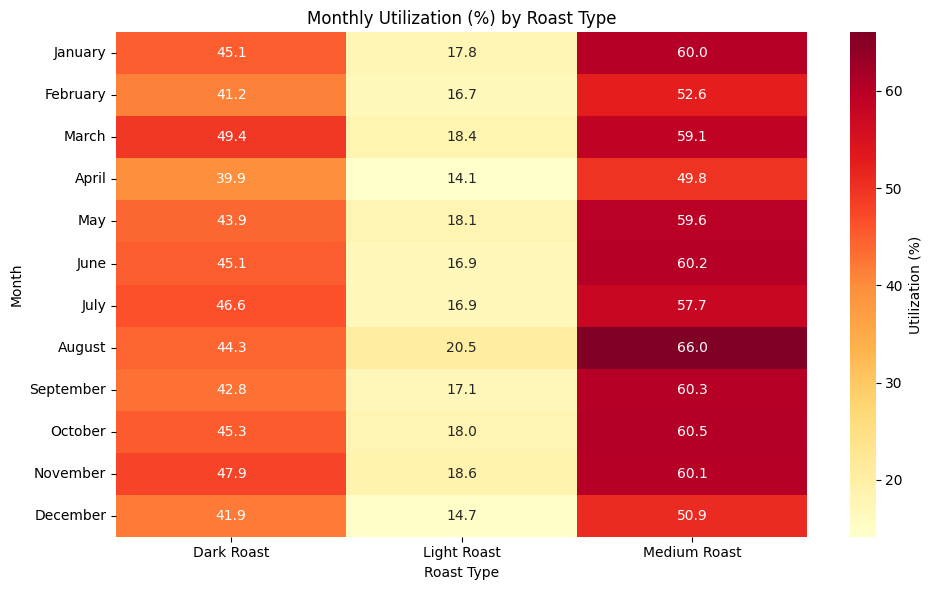

Product type,Dark Roast,Light Roast,Medium Roast
Month,,,
January,45.069198,17.779858,60.049245
February,41.160998,16.686866,52.642109
March,49.388141,18.369608,59.060545
April,39.862958,14.137922,49.832151
May,43.940440,18.054111,59.594042
June,45.091387,16.900783,60.171833
July,46.567575,16.883730,57.671471
August,44.283815,20.528849,66.030196
September,42.752638,17.146814,60.265232


In [55]:
import seaborn as sns

# Prepare data for heatmap (Months as rows, Product types as grouped columns)
utilization_heatmap = monthly_summary.pivot(index="Month", columns="Product type", values="Utilization (%)")
utilization_heatmap = utilization_heatmap.reindex(month_order)  # ensure correct order

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(utilization_heatmap, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Utilization (%)'})
plt.title("Monthly Utilization (%) by Roast Type")
plt.xlabel("Roast Type")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

utilization_heatmap.head(12)


In [56]:
# Load both sales datasets
ecom_df = pd.read_excel(file_path, sheet_name="E-com sales orders by product")
b2b_df = pd.read_excel(file_path, sheet_name="B2B orders")

# Preview structure to see column names for processing
ecom_df.head(), b2b_df.head()


(        Product  Bag type   KG  Quantity   Value Order date Delivery date  \
 0    Dark Roast         2  1.0        11  126.39 2023-01-01    2023-01-02   
 1    Dark Roast         2  1.0         6   68.94 2023-01-01    2023-01-02   
 2    Dark Roast         2  1.0         3   34.47 2023-01-01    2023-01-02   
 3  Medium Roast         2  1.0        10  129.50 2023-01-01    2023-01-02   
 4    Dark Roast         2  1.0         5   57.45 2023-01-01    2023-01-02   
 
    Delivery fee  Shipping costs Ship to (province)  
 0          0.00            6.75       Zuid-Holland  
 1          0.00            6.75         Overijssel  
 2          4.95            6.75            Limburg  
 3          0.00            6.75          Flevoland  
 4          0.00            6.75          Friesland  ,
           Customer             City       Product  Bag type   KG  Quantity  \
 0  NextGen Offices           Arnhem  Medium Roast         1  0.5        56   
 1        DevOffice        Rotterdam  Medium Ro

In [44]:
import pandas as pd

# Reload all necessary data since environment was reset
file_path = "Bean there done that data.xlsx"

# Load needed sheets
roasting_df = pd.read_excel(file_path, sheet_name="Roasting")
ecom_df = pd.read_excel(file_path, sheet_name="E-com sales orders by product")
b2b_df = pd.read_excel(file_path, sheet_name="B2B orders")

# --- RECREATE MONTHLY SUMMARY (Actual & Max capacity) ---
roasting_df["Total time (h)"] = (
    roasting_df["Setup time p/batch"] +
    roasting_df["Run time p/batch (m)"] +
    roasting_df["Cooling time p/batch"]
) / 60

roasting_df["Actual production (kg)"] = (
    roasting_df["Final weight /pbatch"] *
    roasting_df["Number of batches per day"] *
    roasting_df["Workdays"]
)

hours_per_month = 8 * 22
yield_factor = 0.846  # from your observed data

roasting_df["Max capacity (kg)"] = (
    (roasting_df["Load weight p/batch"] * yield_factor / roasting_df["Total time (h)"]) *
    hours_per_month
)

roasting_df["Utilization (%)"] = (roasting_df["Actual production (kg)"] / roasting_df["Max capacity (kg)"]) * 100

monthly_summary = roasting_df.groupby(["Month", "Product type"], as_index=False)[
    ["Actual production (kg)", "Max capacity (kg)"]
].sum()
monthly_summary["Utilization (%)"] = (
    monthly_summary["Actual production (kg)"] / monthly_summary["Max capacity (kg)"]
) * 100


# --- DEMAND CALCULATION ---
# Standardize order dates
for df in [ecom_df, b2b_df]:
    df["Order date"] = pd.to_datetime(df.get("Order date", df.get("Delivery date")))
    df["Month"] = df["Order date"].dt.month_name()

# Calculate demand in kg (bag type 1 = 0.5kg, type 2 = 1kg)
for df in [ecom_df, b2b_df]:
    df["Demand (kg)"] = df["Quantity"] * df["KG"]

# Combine both datasets
demand_df = pd.concat([ecom_df[["Product", "Month", "Demand (kg)"]],
                       b2b_df[["Product", "Month", "Demand (kg)"]]], ignore_index=True)

# Aggregate monthly demand by product type
demand_summary = demand_df.groupby(["Month", "Product"], as_index=False)["Demand (kg)"].sum()

# --- MERGE WITH CAPACITY DATA ---
merged_df = pd.merge(monthly_summary, demand_summary, left_on=["Month", "Product type"], right_on=["Month", "Product"], how="left")

# Calculate coverage ratio
merged_df["Coverage (%)"] = (merged_df["Actual production (kg)"] / merged_df["Demand (kg)"]) * 100

# Clean and sort
merged_df = merged_df.fillna(0)
merged_df = merged_df.sort_values(["Month", "Product type"])

merged_df.head(90)


,Month,Product type,Actual production (kg),Max capacity (kg),Utilization (%),Product,Demand (kg),Coverage (%)
0,April,Dark Roast,28088.811554,29806.035269,94.238671,Dark Roast,34485.5,81.451078
1,April,Light Roast,10218.837448,30574.283220,33.422983,Light Roast,15337.5,66.626487
2,April,Medium Roast,21621.400281,18353.316201,117.806505,Medium Roast,27596.0,78.349762
3,August,Dark Roast,32045.716674,30610.140679,104.689871,Dark Roast,36041.0,88.914616
4,August,Light Roast,14386.691496,29643.993042,48.531557,Light Roast,15723.5,91.498022
5,August,Medium Roast,25823.289952,16542.812776,156.099753,Medium Roast,28093.5,91.919091
6,December,Dark Roast,27863.578354,28104.664858,99.142183,Dark Roast,50106.5,55.608710
7,December,Light Roast,11210.778731,32230.118598,34.783548,Light Roast,21689.5,51.687585
8,December,Medium Roast,20503.628298,17050.556283,120.251961,Medium Roast,39341.0,52.117710
9,February,Dark Roast,28042.767804,28818.763601,97.307324,Dark Roast,45281.0,61.930540


In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your dataframe is merged_df
# Compute coverage percentage
merged_df["Coverage (%)"] = (merged_df["Actual production (kg)"] / merged_df["Demand (kg)"]) * 100

# Sort months in logical order
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
merged_df["Month"] = pd.Categorical(merged_df["Month"], categories=month_order, ordered=True)

# Group by month and product type to get average coverage
coverage_trend = merged_df.groupby(["Month", "Product type"])["Coverage (%)"].mean().reset_index()

# Plot line chart
plt.figure(figsize=(10,6))
for product in coverage_trend["Product type"].unique():
    data = coverage_trend[coverage_trend["Product type"] == product]
    plt.plot(data["Month"], data["Coverage (%)"], marker='o', label=product)

plt.title("Production Coverage vs. Demand by Month")
plt.xlabel("Month")
plt.ylabel("Coverage (%)")
plt.axhline(100, color='gray', linestyle='--', label="Full Demand Met (100%)")
plt.legend(title="Product Type")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


NameError: name 'merged_df' is not defined

In [17]:
# Create clean table with requested columns for all months
comparison_demand_capacity = merged_df[[
    "Month", "Product type", "Actual production (kg)", "Max capacity (kg)", "Demand (kg)", "Coverage (%)"
]].copy()

# Sort by month order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
comparison_demand_capacity["Month"] = pd.Categorical(comparison_demand_capacity["Month"], categories=month_order, ordered=True)
comparison_demand_capacity = comparison_demand_capacity.sort_values(["Month", "Product type"]).reset_index(drop=True)

# Round numbers for clarity
comparison_demand_capacity["Actual production (kg)"] = comparison_demand_capacity["Actual production (kg)"].round(0)
comparison_demand_capacity["Max capacity (kg)"] = comparison_demand_capacity["Max capacity (kg)"].round(0)
comparison_demand_capacity["Demand (kg)"] = comparison_demand_capacity["Demand (kg)"].round(0)
comparison_demand_capacity["Coverage (%)"] = comparison_demand_capacity["Coverage (%)"].round(1)




# Display final table
comparison_demand_capacity.head(15)


,Month,Product type,Actual production (kg),Max capacity (kg),Demand (kg),Coverage (%)
0,January,Dark Roast,31065.0,29156.0,43162.0,72.0
1,January,Light Roast,14162.0,33693.0,18635.0,76.0
2,January,Medium Roast,23162.0,16316.0,34592.0,67.0
3,February,Dark Roast,28043.0,28819.0,45281.0,61.9
4,February,Light Roast,12612.0,31969.0,20036.0,62.9
5,February,Medium Roast,21765.0,17489.0,35597.0,61.1
6,March,Dark Roast,33382.0,28591.0,35151.0,95.0
7,March,Light Roast,14216.0,32735.0,15927.0,89.3
8,March,Medium Roast,23455.0,16799.0,28097.0,83.5
9,April,Dark Roast,28089.0,29806.0,34486.0,81.5


In [9]:
cv_demand = merged_df.groupby("Month")["Demand (kg)"].sum().std() / merged_df["Demand (kg)"].mean()
print(f"Demand stability (CV): {cv_demand:.2f}")


Demand stability (CV): 0.48


In [18]:
overproduction_rate = (merged_df["Coverage (%)"] > 100).mean() * 100
print(f"Share of months with overproduction: {overproduction_rate:.1f}%")


Share of months with overproduction: 0.0%


In [19]:
roasting = pd.read_excel(file_path, sheet_name="Roasting")
avg_workdays = roasting["Workdays"].mean()
max_possible = 30  # assume full-month operations
workday_utilization = avg_workdays / max_possible * 100
print(f"Average workday utilization: {workday_utilization:.1f}%")


Average workday utilization: 70.6%


In [42]:
supplier_issue = merged_df[
    (merged_df["Demand (kg)"] > merged_df["Actual production (kg)"]) &
    (merged_df["Utilization (%)"] < 80)
]
issue_months = supplier_issue["Month"].nunique()
print(f"Months with probable supplier issues: {issue_months}")


NameError: name 'merged_df' is not defined

In [39]:
import pandas as pd

# === 1️⃣ Načtení dat ===
file_path = "Bean there done that data.xlsx"

# Načteme sheet s pražením
roasting = pd.read_excel(file_path, sheet_name="Roasting")

# Ověření sloupců (přizpůsobíme názvy, pokud mají jiné formátování)
roasting.columns = roasting.columns.str.strip().str.lower().str.replace(' ', '_')

# === 2️⃣ Parametry ===
hours_per_day = 8
yield_factor = 0.846  # průměrný výtěžek po pražení (84.6 %)

machine_capacity = {
    'Probat P60': 215,     # kg/h (vstup)
    'Probat Px120': 470    # kg/h (vstup)
}

max_batch_size = {
    'Probat P60': 60,      # kg/batch (vstup)
    'Probat Px120': 120
}

# === 3️⃣ Výpočty kapacity a produkce ===

# Maximální možná produkce (včetně yield faktoru)
roasting['max_possible_production'] = roasting.apply(
    lambda row: machine_capacity[row['machine']] * hours_per_day * row['workdays'] * yield_factor,
    axis=1
)

# Skutečná produkce
roasting['actual_production'] = (
    roasting['final_weight_/pbatch'] *
    roasting['number_of_batches_per_day'] *
    roasting['workdays']
)

# Kapacita podle batchů
roasting['max_possible_kg'] = (
    roasting['machine'].map(max_batch_size) *
    roasting['number_of_batches_per_day'] *
    roasting['workdays'] *
    yield_factor
)

roasting['actual_kg'] = (
    roasting['final_weight_/pbatch'] *
    roasting['number_of_batches_per_day'] *
    roasting['workdays']
)

# Využití a rozdíly
roasting['missed_kg'] = roasting['max_possible_kg'] - roasting['actual_kg']
roasting['utilization_rate'] = roasting['actual_kg'] / roasting['max_possible_kg']

# === 4️⃣ Měsíční přehled podle typu produktu ===
monthly_utilization = (
    roasting.groupby(['month', 'product_type'])[['actual_kg', 'max_possible_kg']]
    .sum()
    .assign(utilization_rate=lambda x: x['actual_kg'] / x['max_possible_kg'])
    .reset_index()
)

print("📅 Měsíční využití po typu produktu:")
print(monthly_utilization)
print()

# === 5️⃣ Celkové využití podle typu produktu ===
overall_utilization = (
    roasting.groupby('product_type')[['actual_kg', 'max_possible_kg']]
    .sum()
    .assign(utilization_rate=lambda x: x['actual_kg'] / x['max_possible_kg'])
    .reset_index()
)

print("☕ Celkové využití po typu produktu:")
print(overall_utilization)
print()

# === 6️⃣ Celkové shrnutí firmy ===
totals = roasting[['actual_kg', 'max_possible_kg']].sum()
overall_rate = totals['actual_kg'] / totals['max_possible_kg']

print(f"🏭 Celková využitelnost všech produktů dohromady: {overall_rate:.2%}")


📅 Měsíční využití po typu produktu:
        month  product_type     actual_kg  max_possible_kg  utilization_rate
0       April    Dark Roast  28088.811554         30456.00          0.922275
1       April   Light Roast  10218.837448         10964.16          0.932022
2       April  Medium Roast  21621.400281         23197.32          0.932065
3      August    Dark Roast  32045.716674         36445.68          0.879273
4      August   Light Roast  14386.691496         15837.12          0.908416
5      August  Medium Roast  25823.289952         28121.04          0.918291
6    December    Dark Roast  27863.578354         32384.88          0.860389
7    December   Light Roast  11210.778731         12385.44          0.905158
8    December  Medium Roast  20503.628298         23248.08          0.881949
9    February    Dark Roast  28042.767804         32790.96          0.855198
10   February   Light Roast  12611.581979         13705.20          0.920204
11   February  Medium Roast  21764.50654

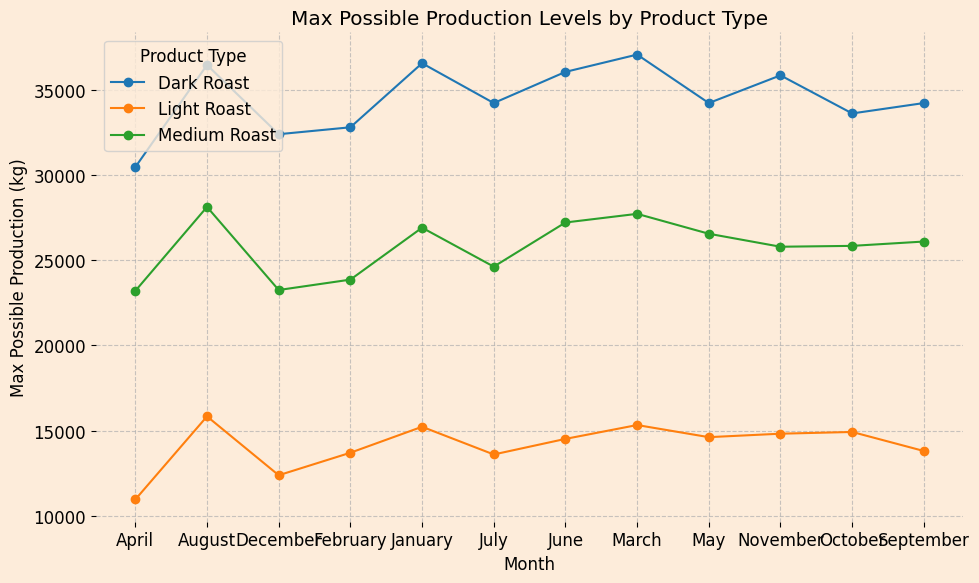

In [40]:
import matplotlib.pyplot as plt

# === 7️⃣ Line chart of max production levels ===
plt.figure(figsize=(10, 6))

for product in monthly_utilization['product_type'].unique():
    subset = monthly_utilization[monthly_utilization['product_type'] == product]
    plt.plot(subset['month'], subset['max_possible_kg'], marker='o', label=product)

plt.title('Max Possible Production Levels by Product Type')
plt.xlabel('Month')
plt.ylabel('Max Possible Production (kg)')
plt.legend(title='Product Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [41]:
import pandas as pd

# Reload all necessary data since environment was reset
file_path = "Bean there done that data.xlsx"

# Load needed sheets
roasting_df = pd.read_excel(file_path, sheet_name="Roasting")
ecom_df = pd.read_excel(file_path, sheet_name="E-com sales orders by product")
b2b_df = pd.read_excel(file_path, sheet_name="B2B orders")

# --- RECREATE MONTHLY SUMMARY (Actual & Max capacity) ---
roasting_df["Total time (h)"] = (
    roasting_df["Setup time p/batch"] +
    roasting_df["Run time p/batch (m)"] +
    roasting_df["Cooling time p/batch"]
) / 60

roasting_df["Actual production (kg)"] = (
    roasting_df["Final weight /pbatch"] *
    roasting_df["Number of batches per day"] *
    roasting_df["Workdays"]
)
# --- DEMAND CALCULATION ---
# Standardize order dates
for df in [ecom_df, b2b_df]:
    df["Order date"] = pd.to_datetime(df.get("Order date", df.get("Delivery date")))
    df["Month"] = df["Order date"].dt.month_name()

# Calculate demand in kg (bag type 1 = 0.5kg, type 2 = 1kg)
for df in [ecom_df, b2b_df]:
    df["Demand (kg)"] = df["Quantity"] * df["KG"]

# Combine both datasets
demand_df = pd.concat([ecom_df[["Product", "Month", "Demand (kg)"]],
                       b2b_df[["Product", "Month", "Demand (kg)"]]], ignore_index=True)

# Aggregate monthly demand by product type
demand_summary = demand_df.groupby(["Month", "Product"], as_index=False)["Demand (kg)"].sum()

# --- MERGE WITH CAPACITY DATA ---
merged_df = pd.merge(monthly_summary, demand_summary, left_on=["Month", "Product type"], right_on=["Month", "Product"], how="left")

# Calculate coverage ratio
merged_df["Coverage (%)"] = (merged_df["Actual production (kg)"] / merged_df["Demand (kg)"]) * 100

NameError: name 'monthly_summary' is not defined

C:\Users\matej\AppData\Local\Temp\ipykernel_23448\3158772743.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_totals = merged_df.groupby("Month", as_index=False)[["Actual production (kg)", "Demand (kg)"]].sum()


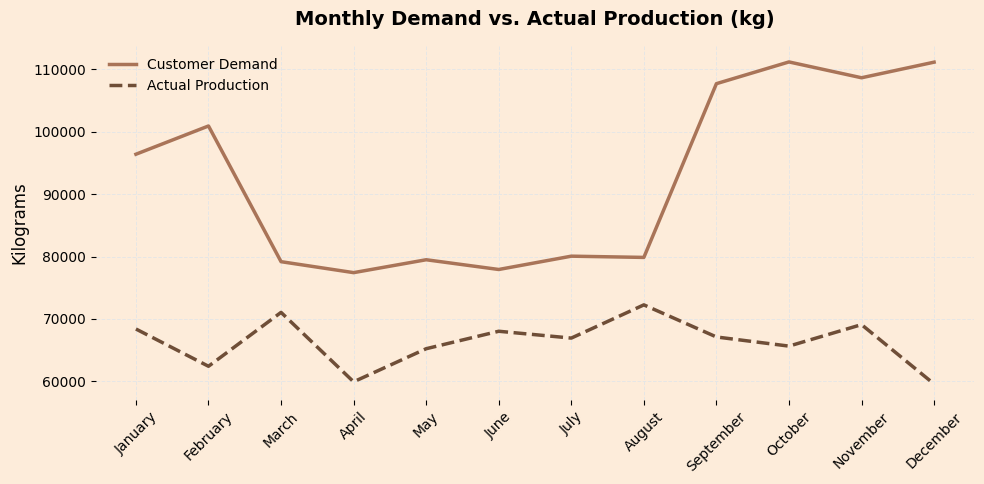

In [45]:
import matplotlib.pyplot as plt

# === Clean coffee-inspired colors ===
colors = {
    "Demand": "#A97458",        # caramel brown
    "Production": "#6F4E37"     # espresso brown
}

# Sort months chronologically (if needed)
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
merged_df["Month"] = pd.Categorical(merged_df["Month"], categories=month_order, ordered=True)
merged_df = merged_df.sort_values("Month")

# === Aggregate overall monthly totals ===
monthly_totals = merged_df.groupby("Month", as_index=False)[["Actual production (kg)", "Demand (kg)"]].sum()

# === Line chart ===
plt.figure(figsize=(10, 5))
plt.plot(monthly_totals["Month"], monthly_totals["Demand (kg)"], 
         label="Customer Demand", color=colors["Demand"], linestyle="-", linewidth=2.5)
plt.plot(monthly_totals["Month"], monthly_totals["Actual production (kg)"], 
         label="Actual Production", color=colors["Production"], linestyle="--", linewidth=2.5)

# === Style ===
plt.title("Monthly Demand vs. Actual Production (kg)", fontsize=14, weight="bold", pad=15)
plt.ylabel("Kilograms", fontsize=12)
plt.grid(True, color="#E6E6E6", linestyle="--", linewidth=0.7)

# Remove frames and clutter
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.box(False)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(frameon=False, fontsize=10, loc="upper left")

plt.tight_layout()
plt.show()


C:\Users\matej\AppData\Local\Temp\ipykernel_23448\959753765.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_totals = merged_df.groupby("Month", as_index=False)[["Actual production (kg)", "Demand (kg)"]].sum()


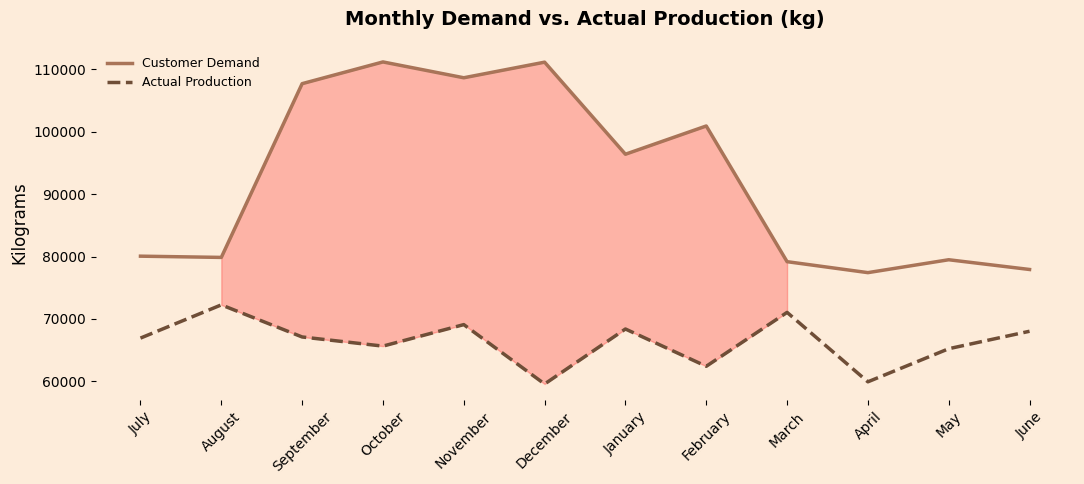

In [46]:
import matplotlib.pyplot as plt

# === Coffee-inspired colors ===
colors = {
    "Demand": "#A97458",        # caramel brown
    "Production": "#6F4E37"     # espresso brown
}

# === Reorder months ===
custom_order = [
    "July","August","September","October","November",
    "December","January","February","March","April","May","June"
]
merged_df["Month"] = pd.Categorical(merged_df["Month"], categories=custom_order, ordered=True)
merged_df = merged_df.sort_values("Month")

# === Aggregate totals per month ===
monthly_totals = merged_df.groupby("Month", as_index=False)[["Actual production (kg)", "Demand (kg)"]].sum()

# === Highlight months (Aug–Mar) ===
highlight_months = ["August","September","October","November","December","January","February","March"]
highlight_mask = monthly_totals["Month"].isin(highlight_months)

# === Plot ===
plt.figure(figsize=(11, 5))

# --- Base lines ---
plt.plot(monthly_totals["Month"], monthly_totals["Demand (kg)"], 
         label="Customer Demand", color=colors["Demand"], linewidth=2.5)
plt.plot(monthly_totals["Month"], monthly_totals["Actual production (kg)"], 
         label="Actual Production", color=colors["Production"], linestyle="--", linewidth=2.5)

# --- Dark red fill between lines for Aug–Mar ---
plt.fill_between(
    monthly_totals["Month"],
    monthly_totals["Demand (kg)"],
    monthly_totals["Actual production (kg)"],
    where=highlight_mask,
    color="#FF0C0C32",  # dark red
    alpha=0.25
)

# === Clean minimalist style ===
plt.title("Monthly Demand vs. Actual Production (kg)", fontsize=14, weight="bold", pad=15)
plt.ylabel("Kilograms", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Remove grid, frame, and box
plt.grid(False)
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.box(False)

plt.legend(frameon=False, fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()


C:\Users\matej\AppData\Local\Temp\ipykernel_23448\1690900821.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_totals = merged_df.groupby("Month", as_index=False)[["Actual production (kg)", "Demand (kg)"]].sum()


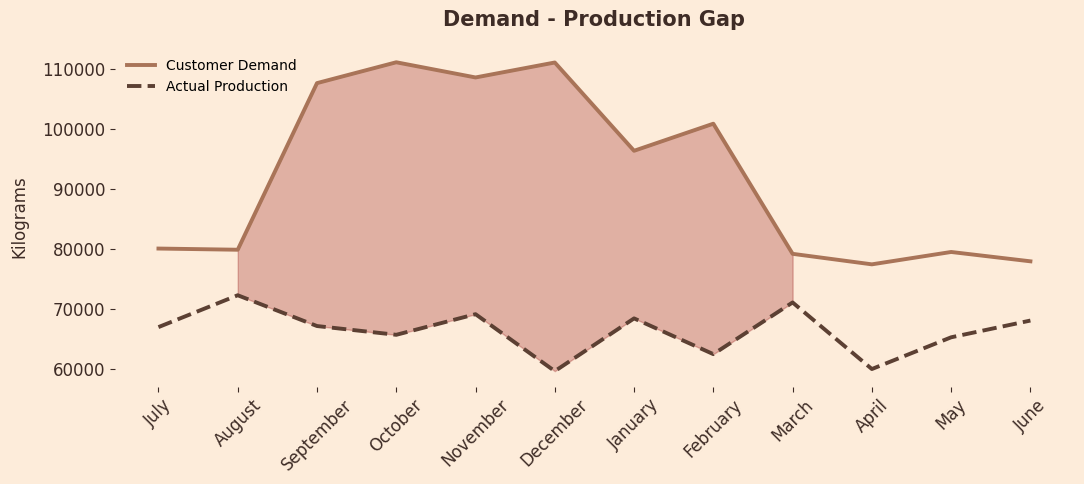

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

# === Coffee-inspired palette ===
colors = { 
    "Demand": "#A97458",        # caramel brown
    "Production": "#5C4033",    # espresso brown
    "Background": "#FDEcDA",    # creamy beige (slide background)
    "Text": "#3E2C26"           # dark chocolate for labels
}

# === Ensure correct month order ===
custom_order = [
    "July","August","September","October","November",
    "December","January","February","March","April","May","June"
]
merged_df["Month"] = pd.Categorical(merged_df["Month"], categories=custom_order, ordered=True)
merged_df = merged_df.sort_values("Month")

# === Aggregate totals per month ===
monthly_totals = merged_df.groupby("Month", as_index=False)[["Actual production (kg)", "Demand (kg)"]].sum()

# === Identify highlight period (Aug–Mar) ===
highlight_months = ["August","September","October","November","December","January","February","March"]
highlight_mask = monthly_totals["Month"].isin(highlight_months)

# === Apply consistent visual style ===
plt.style.use("default")
plt.rcParams.update({
    "axes.facecolor": colors["Background"],
    "figure.facecolor": colors["Background"],
    "axes.edgecolor": "none",
    "axes.labelcolor": colors["Text"],
    "xtick.color": colors["Text"],
    "ytick.color": colors["Text"],
    "font.family": "sans-serif",
    "font.size": 12
})

# === Plot ===
fig, ax = plt.subplots(figsize=(11, 5))

# Demand line
ax.plot(monthly_totals["Month"], monthly_totals["Demand (kg)"], 
        label="Customer Demand", color=colors["Demand"], linewidth=2.8)

# Production line
ax.plot(monthly_totals["Month"], monthly_totals["Actual production (kg)"], 
        label="Actual Production", color=colors["Production"], linestyle="--", linewidth=2.8)

# Fill between (highlight period)
ax.fill_between(
    monthly_totals["Month"],
    monthly_totals["Demand (kg)"],
    monthly_totals["Actual production (kg)"],
    where=highlight_mask,
    color="#8B000030",  # transparent deep red-brown
    alpha=0.25
)

# === Clean visual finish ===
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)
ax.tick_params(axis="x", rotation=45)

ax.set_title("Demand - Production Gap",
             fontsize=15, fontweight="bold", color=colors["Text"], pad=15)
ax.set_ylabel("Kilograms", fontsize=12, labelpad=10)
ax.legend(frameon=False, fontsize=10, loc="upper left")

plt.tight_layout()
plt.show()


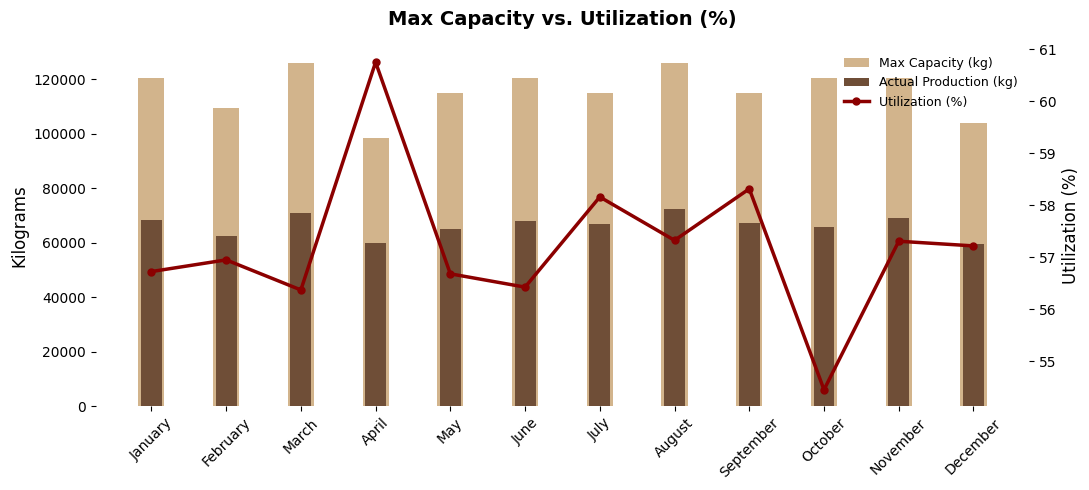

In [78]:
import matplotlib.pyplot as plt
import pandas as pd

# === Example dataframe ===
data = {
    "month": ["January","February","March","April","May","June","July","August",
              "September","October","November","December"],
    "actual_produced_kg": [68389.623244,62418.856327,71052.363722,59929.049283,
                           65231.038671,68028.585644,66933.562978,72255.698122,
                           67113.076858,65648.146070,69093.214827,59577.985382],
    "max_possible_kg": [120560,109600,126040,98640,115080,120560,115080,126040,
                        115080,120560,120560,104120],
    "utilization_rate": [0.567266,0.569515,0.563729,0.607553,0.566832,0.564272,
                         0.581626,0.573276,0.583186,0.544527,0.573102,0.572205]
}
df = pd.DataFrame(data)

# === Colors ===
brown = "#6F4E37"       # espresso brown for actual production
latte = "#D2B48C"       # light beige for max capacity
accent = "#8B0000"      # dark red for utilization line

# === Plot setup ===
fig, ax1 = plt.subplots(figsize=(11,5))
x = range(len(df))
bar_width = 0.35

# --- Bars for capacity and production ---
ax1.bar(x, df["max_possible_kg"], width=bar_width, color=latte, label="Max Capacity (kg)")
ax1.bar(x, df["actual_produced_kg"], width=bar_width*0.8, color=brown, label="Actual Production (kg)")

# --- Line for utilization (%) ---
ax2 = ax1.twinx()
ax2.plot(x, df["utilization_rate"]*100, color=accent, linewidth=2.5, 
         label="Utilization (%)", linestyle="-", marker="o", markersize=5)

# === Axes labels ===
ax1.set_xticks(x)
ax1.set_xticklabels(df["month"], rotation=45, fontsize=10)
ax1.set_ylabel("Kilograms", fontsize=12)
ax2.set_ylabel("Utilization (%)", fontsize=12)

# === Remove grid and frames ===
ax1.grid(False)
ax2.grid(False)
for spine in ax1.spines.values():
    spine.set_visible(False)
for spine in ax2.spines.values():
    spine.set_visible(False)

# === Title and legend ===
plt.title("Max Capacity vs. Utilization (%)", fontsize=14, weight="bold", pad=15)
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.legend(lines, labels, frameon=False, loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


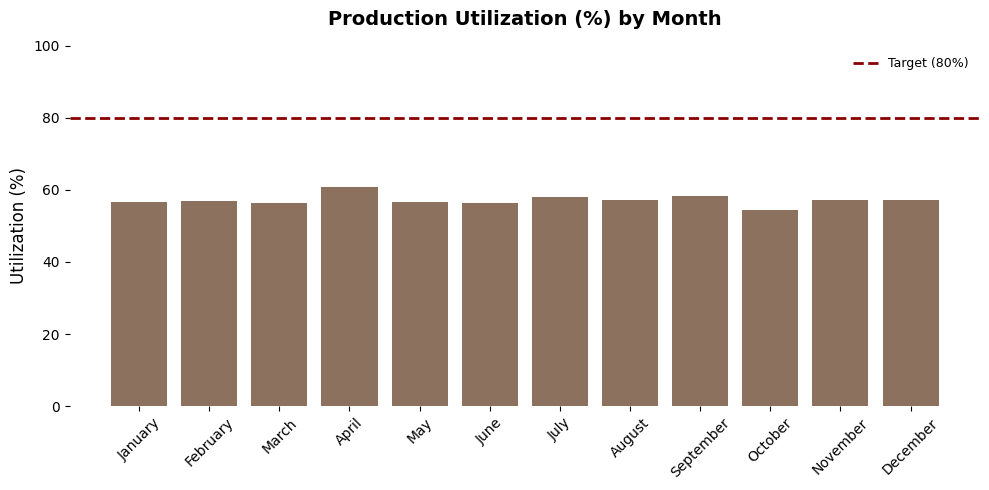

In [79]:
plt.figure(figsize=(10,5))

plt.bar(df["month"], df["utilization_rate"]*100, color="#6F4E37", alpha=0.8)
plt.axhline(80, color="#8B0000", linestyle="--", linewidth=2, label="Target (80%)")

plt.title("Production Utilization (%) by Month", fontsize=14, weight="bold", pad=15)
plt.ylabel("Utilization (%)", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 100)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.legend(frameon=False, fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()


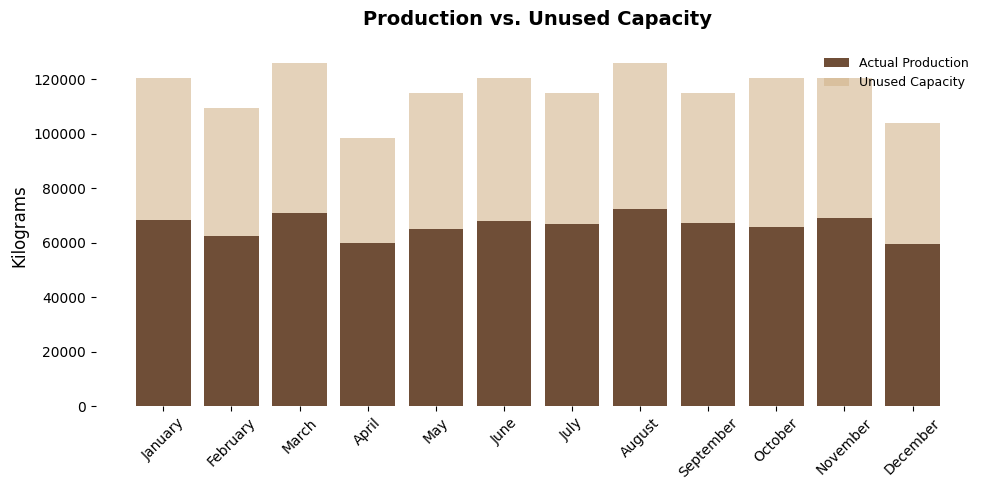

In [80]:
plt.figure(figsize=(10,5))

unused = df["max_possible_kg"] - df["actual_produced_kg"]
plt.bar(df["month"], df["actual_produced_kg"], color="#6F4E37", label="Actual Production")
plt.bar(df["month"], unused, bottom=df["actual_produced_kg"], color="#D2B48C", alpha=0.6, label="Unused Capacity")

plt.title("Production vs. Unused Capacity", fontsize=14, weight="bold", pad=15)
plt.ylabel("Kilograms", fontsize=12)
plt.xticks(rotation=45)
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.legend(frameon=False, fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()


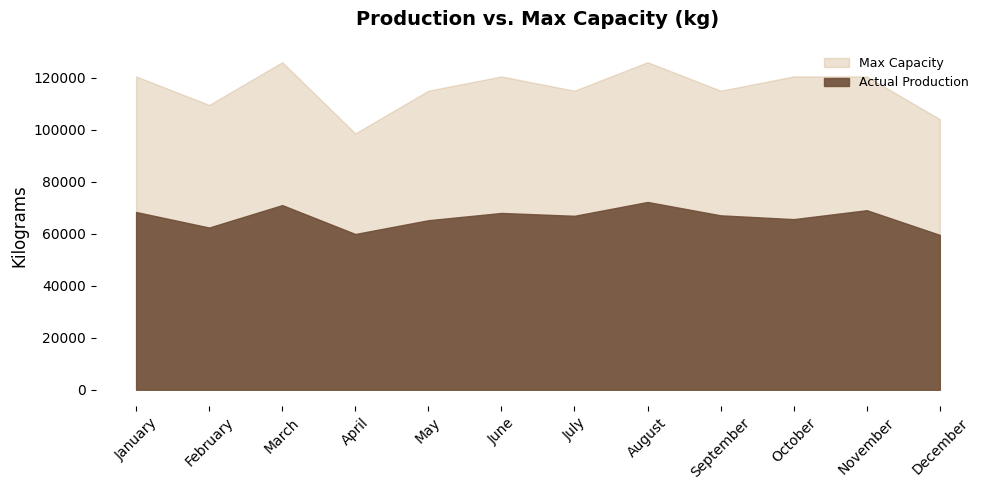

In [81]:
plt.figure(figsize=(10,5))

plt.fill_between(df["month"], df["max_possible_kg"], color="#D2B48C", alpha=0.4, label="Max Capacity")
plt.fill_between(df["month"], df["actual_produced_kg"], color="#6F4E37", alpha=0.9, label="Actual Production")

plt.title("Production vs. Max Capacity (kg)", fontsize=14, weight="bold", pad=15)
plt.ylabel("Kilograms", fontsize=12)
plt.xticks(rotation=45)
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.legend(frameon=False, fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()


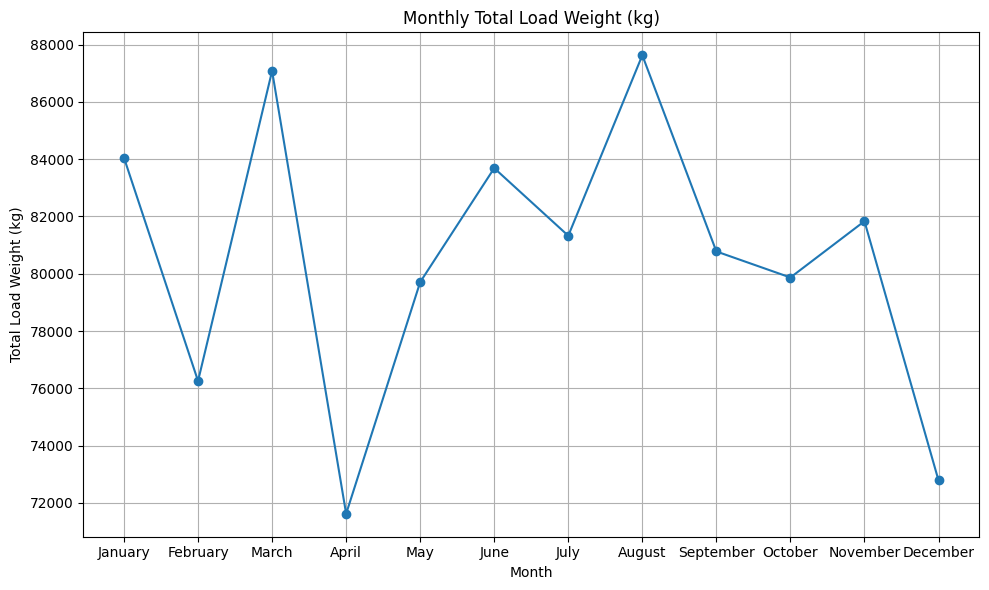

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
file_path = "Bean there done that data.xlsx"
roasting = pd.read_excel(file_path, sheet_name="Roasting")

# Standardize column names
roasting.columns = roasting.columns.str.strip().str.lower().str.replace(" ", "_")

# Compute total load weight per month
roasting["total_load_weight"] = roasting["load_weight_p/batch"] * roasting["number_of_batches_per_day"] * roasting["workdays"]

# Group by month
monthly_load = roasting.groupby("month")["total_load_weight"].sum().reset_index()

# Sort by month order if needed
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
monthly_load["month"] = pd.Categorical(monthly_load["month"], categories=month_order, ordered=True)
monthly_load = monthly_load.sort_values("month")

# Line chart
plt.figure(figsize=(10,6))
plt.plot(monthly_load["month"], monthly_load["total_load_weight"], marker="o", linestyle="-")
plt.title("Monthly Total Load Weight (kg)")
plt.xlabel("Month")
plt.ylabel("Total Load Weight (kg)")
plt.grid(True)
plt.tight_layout()
plt.show()


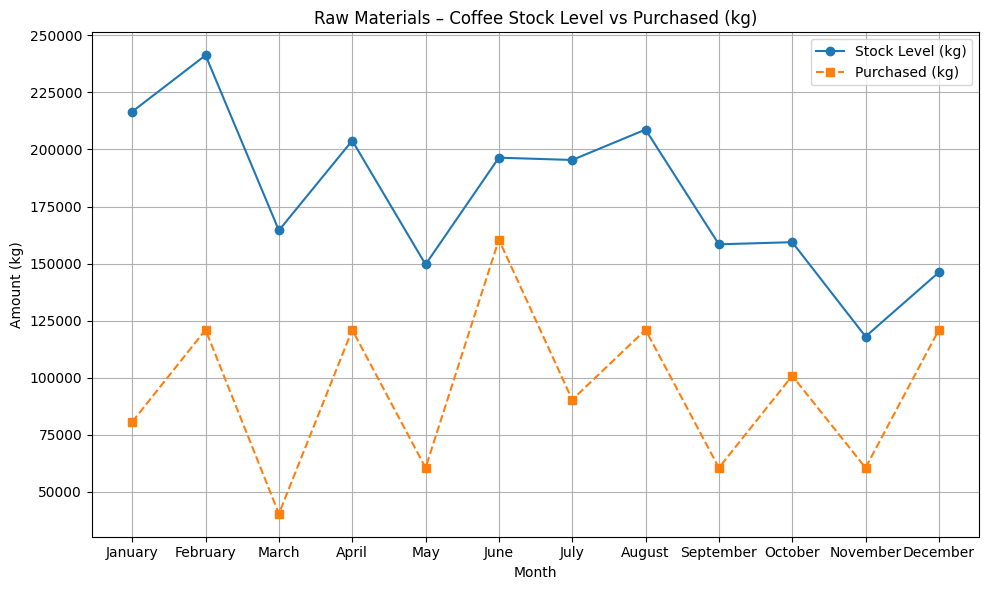

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data file
file_path = "Bean there done that data.xlsx"

# Load Raw materials sheet
raw_materials = pd.read_excel(file_path, sheet_name="Inventory (raw material)")

# Standardize column names
raw_materials.columns = raw_materials.columns.str.strip().str.lower().str.replace(" ", "_")

# Filter only coffee-related products
coffee_raw = raw_materials[raw_materials["product"].str.contains("coffee", case=False, na=False)]

# Group by month: stock level and purchased
monthly_stock = coffee_raw.groupby("month")[["stock_level", "purchased"]].sum().reset_index()

# Sort by month
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
monthly_stock["month"] = pd.Categorical(monthly_stock["month"], categories=month_order, ordered=True)
monthly_stock = monthly_stock.sort_values("month")

# Plot both stock level and purchased
plt.figure(figsize=(10,6))
plt.plot(monthly_stock["month"], monthly_stock["stock_level"], marker="o", linestyle="-", label="Stock Level (kg)")
plt.plot(monthly_stock["month"], monthly_stock["purchased"], marker="s", linestyle="--", label="Purchased (kg)")
plt.title("Raw Materials – Coffee Stock Level vs Purchased (kg)")
plt.xlabel("Month")
plt.ylabel("Amount (kg)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


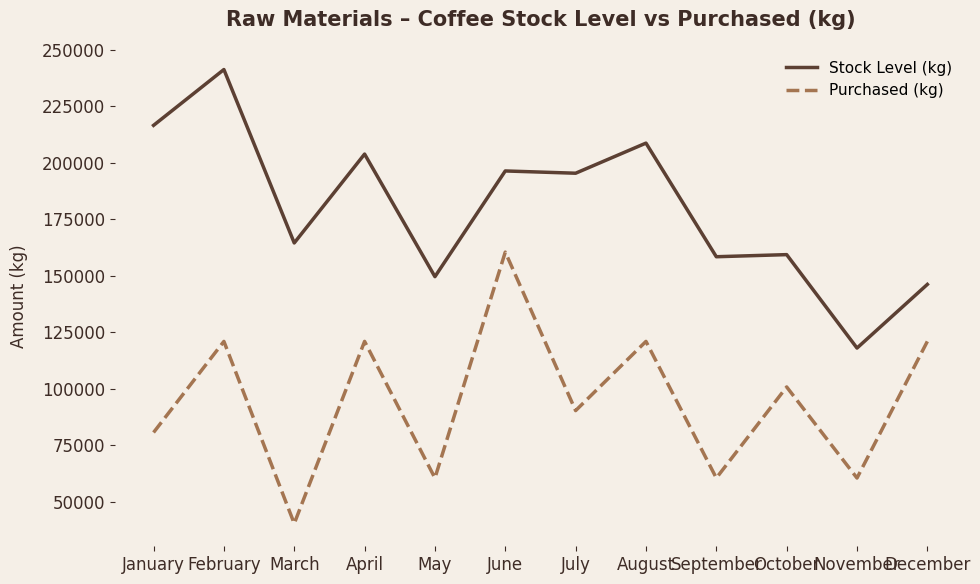

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1️⃣ Load and prepare data ===
file_path = "Bean there done that data.xlsx"
raw_materials = pd.read_excel(file_path, sheet_name="Inventory (raw material)")

# Standardize column names
raw_materials.columns = raw_materials.columns.str.strip().str.lower().str.replace(" ", "_")

# Filter only coffee-related products
coffee_raw = raw_materials[raw_materials["product"].str.contains("coffee", case=False, na=False)]

# Group by month
monthly_stock = coffee_raw.groupby("month")[["stock_level", "purchased"]].sum().reset_index()

# Sort months correctly
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
monthly_stock["month"] = pd.Categorical(monthly_stock["month"], categories=month_order, ordered=True)
monthly_stock = monthly_stock.sort_values("month")

# === 2️⃣ Style setup (presentation colors) ===
bg_color = "#F5EFE7"        # creamy-beige background (matches slide)
brown = "#5C4033"           # rich coffee-brown line
light_brown = "#A47551"     # lighter tone for second line
text_color = "#3E2C26"      # deep brown text

plt.style.use("default")
plt.rcParams.update({
    "axes.facecolor": bg_color,
    "figure.facecolor": bg_color,
    "axes.edgecolor": "none",
    "axes.labelcolor": text_color,
    "xtick.color": text_color,
    "ytick.color": text_color,
    "font.family": "sans-serif",
    "font.size": 12
})

# === 3️⃣ Plot ===
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(monthly_stock["month"], monthly_stock["stock_level"],
        color=brown, linewidth=2.5, label="Stock Level (kg)")
ax.plot(monthly_stock["month"], monthly_stock["purchased"],
        color=light_brown, linewidth=2.5, linestyle="--", label="Purchased (kg)")

# Remove all visual clutter
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.grid(False)

# Labels and legend
ax.set_title("Raw Materials – Coffee Stock Level vs Purchased (kg)",
             fontsize=15, fontweight="bold", color=text_color, pad=15)
ax.set_xlabel("")
ax.set_ylabel("Amount (kg)", fontsize=12, labelpad=10)
ax.legend(frameon=False, loc="upper right", fontsize=11)

plt.tight_layout()
plt.show()


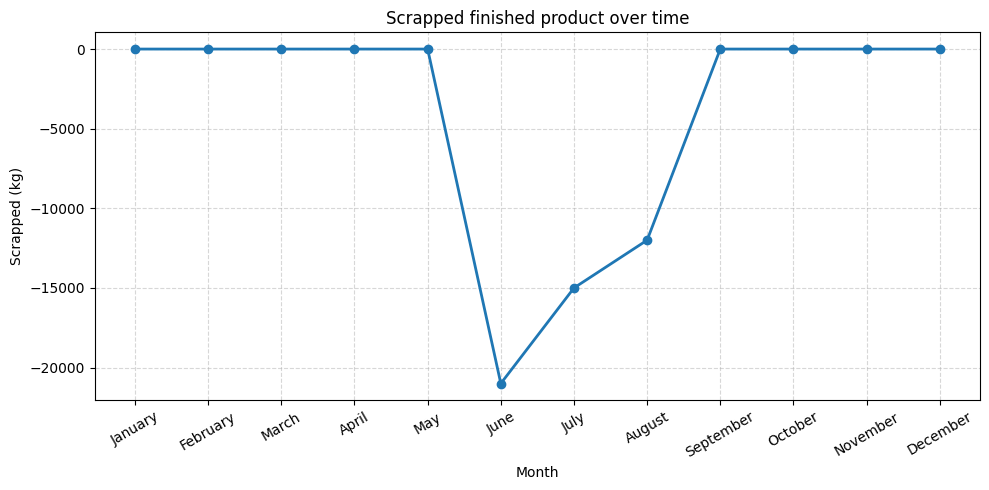

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Načtení dat
file_path = "Bean there done that data.xlsx"   # pokud máš jinde, uprav cestu
inv_fp = pd.read_excel(file_path, sheet_name="Inventory (finished product)")

# 2) Ujistíme se, že máme sloupce pro čas a scrapped
# Předpoklad: je tam sloupec "Month" (textově) a sloupec "Scrapped"
# pokud je sloupec jinak pojmenovaný (např. "scrapped_kg"), jen přejmenuj v řádku níže
inv_fp.columns = inv_fp.columns.str.strip()

# 3) Převedeme měsíc na pořadí, aby se to správně seřadilo
month_order = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}

inv_fp["month_num"] = inv_fp["Month"].map(month_order)

# 4) Agregace – kolik se sešrotovalo za měsíc (celkem pro všechny produkty)
scrap_by_month = (
    inv_fp
    .groupby(["month_num", "Month"])["Scrapped"]
    .sum()
    .reset_index()
    .sort_values("month_num")
)

# 5) Line chart
plt.figure(figsize=(10, 5))
plt.plot(scrap_by_month["Month"], scrap_by_month["Scrapped"],
         marker="o", linewidth=2)

plt.title("Scrapped finished product over time")
plt.xlabel("Month")
plt.ylabel("Scrapped (kg)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


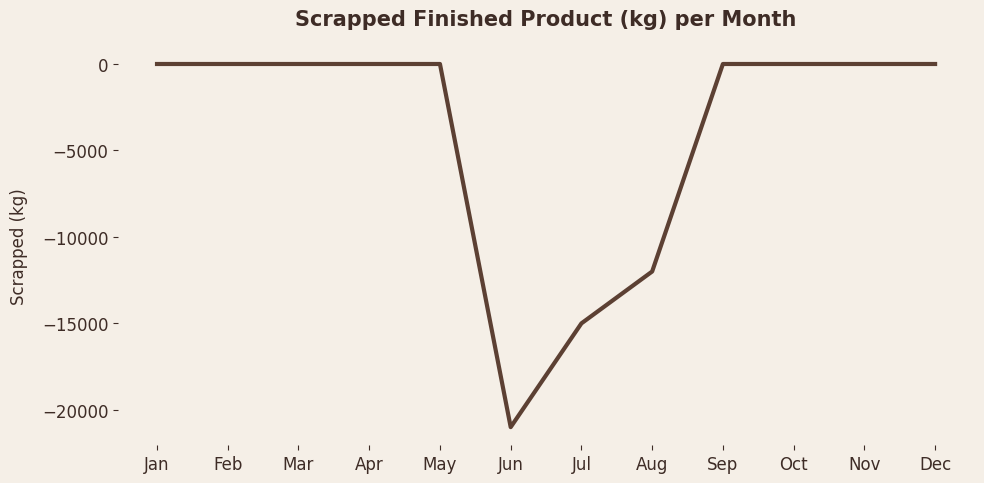

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1️⃣ Load data ===
file_path = "Bean there done that data.xlsx"
inv_fp = pd.read_excel(file_path, sheet_name="Inventory (finished product)")

# === 2️⃣ Clean column names ===
inv_fp.columns = inv_fp.columns.str.strip()

# === 3️⃣ Convert full month names → numeric order + abbreviations ===
month_order = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}
month_abbr = {
    "January": "Jan", "February": "Feb", "March": "Mar", "April": "Apr",
    "May": "May", "June": "Jun", "July": "Jul", "August": "Aug",
    "September": "Sep", "October": "Oct", "November": "Nov", "December": "Dec"
}

inv_fp["month_num"] = inv_fp["Month"].map(month_order)
inv_fp["Month_abbr"] = inv_fp["Month"].map(month_abbr)

# === 4️⃣ Aggregate scrapped by month ===
scrap_by_month = (
    inv_fp.groupby(["month_num", "Month_abbr"])["Scrapped"]
    .sum()
    .reset_index()
    .sort_values("month_num")
)

# === 5️⃣ Coffee color palette (matches your presentation) ===
bg_color = "#F5EFE7"        # beige background
brown = "#5C4033"           # espresso line
text_color = "#3E2C26"      # dark brown labels

# === 6️⃣ Global style settings ===
plt.style.use("default")
plt.rcParams.update({
    "axes.facecolor": bg_color,
    "figure.facecolor": bg_color,
    "axes.edgecolor": "none",
    "axes.labelcolor": text_color,
    "xtick.color": text_color,
    "ytick.color": text_color,
    "font.family": "sans-serif",
    "font.size": 12
})

# === 7️⃣ Plot ===
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(scrap_by_month["Month_abbr"], scrap_by_month["Scrapped"],
        color=brown, linewidth=3)

# === 8️⃣ Clean minimalist style ===
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

ax.set_title("Scrapped Finished Product (kg) per Month",
             fontsize=15, fontweight="bold", color=text_color, pad=15)
ax.set_xlabel("")
ax.set_ylabel("Scrapped (kg)", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()



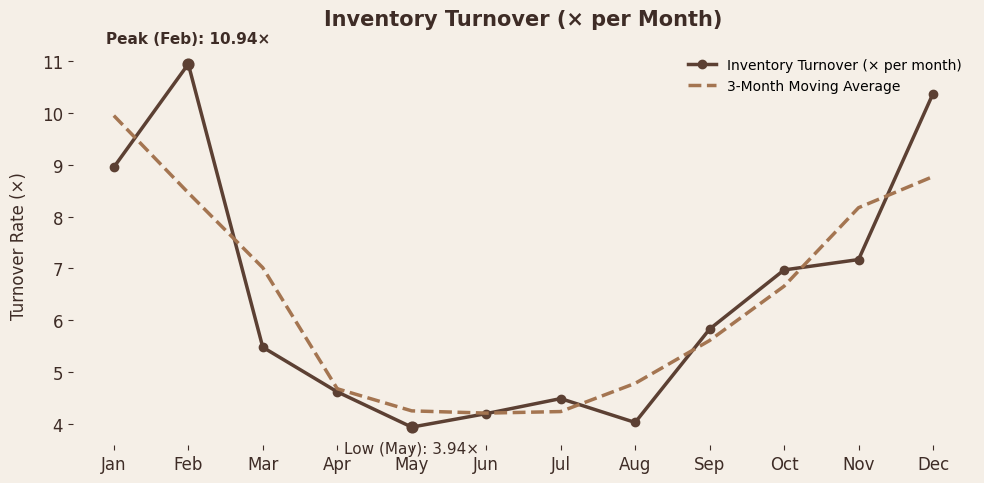

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1️⃣ Data ===
data = {
    "Month": ["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"],
    "Turnover": [8.95, 10.94, 5.48, 4.62, 3.94, 4.20, 4.49, 4.03, 5.83, 6.97, 7.17, 10.37]
}
df = pd.DataFrame(data)

# === 2️⃣ Coffee color palette ===
colors = {
    "line": "#5C4033",        # espresso brown
    "avg": "#A47551",         # caramel brown
    "bg": "#F5EFE7",          # beige background
    "text": "#3E2C26"         # dark chocolate text
}

# === 3️⃣ Global style ===
plt.style.use("default")
plt.rcParams.update({
    "axes.facecolor": colors["bg"],
    "figure.facecolor": colors["bg"],
    "axes.edgecolor": "none",
    "axes.labelcolor": colors["text"],
    "xtick.color": colors["text"],
    "ytick.color": colors["text"],
    "font.family": "sans-serif",
    "font.size": 12
})

# === 4️⃣ 3-month moving average ===
df["Turnover_MA3"] = df["Turnover"].rolling(3, center=True, min_periods=1).mean()

# === 5️⃣ Plot ===
fig, ax = plt.subplots(figsize=(10, 5))

# Main line
ax.plot(df["Month"], df["Turnover"], color=colors["line"], linewidth=2.5,
        label="Inventory Turnover (× per month)", marker="o", markersize=6)

# Moving average line
ax.plot(df["Month"], df["Turnover_MA3"], color=colors["avg"], linewidth=2.5,
        linestyle="--", label="3-Month Moving Average")

# === 6️⃣ Highlight peak and low ===
peak_idx = df["Turnover"].idxmax()
low_idx = df["Turnover"].idxmin()

ax.scatter(df.loc[peak_idx, "Month"], df.loc[peak_idx, "Turnover"],
           color=colors["line"], s=60)
ax.scatter(df.loc[low_idx, "Month"], df.loc[low_idx, "Turnover"],
           color=colors["line"], s=60)

ax.text(df.loc[peak_idx, "Month"], df.loc[peak_idx, "Turnover"] + 0.4,
        f"Peak ({df.loc[peak_idx, 'Month']}): {df.loc[peak_idx, 'Turnover']:.2f}×",
        color=colors["text"], fontsize=11, ha="center", weight="bold")

ax.text(df.loc[low_idx, "Month"], df.loc[low_idx, "Turnover"] - 0.5,
        f"Low ({df.loc[low_idx, 'Month']}): {df.loc[low_idx, 'Turnover']:.2f}×",
        color=colors["text"], fontsize=11, ha="center")

# === 7️⃣ Clean minimalist style ===
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

ax.set_title("Inventory Turnover (× per Month)", fontsize=15, fontweight="bold", color=colors["text"], pad=15)
ax.set_ylabel("Turnover Rate (×)", fontsize=12, labelpad=10)
ax.set_xlabel("")
ax.legend(frameon=False, fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()


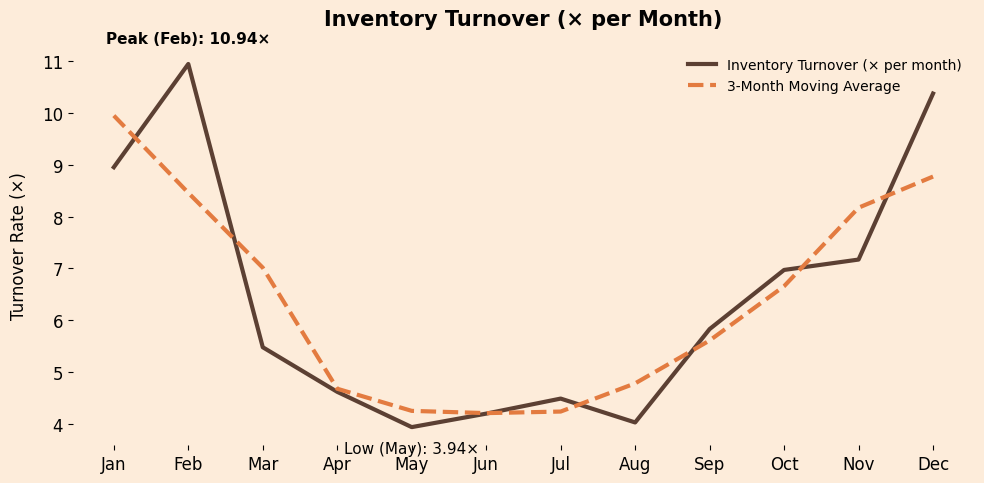

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1️⃣ Data ===
data = {
    "Month": ["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"],
    "Turnover": [8.95, 10.94, 5.48, 4.62, 3.94, 4.20, 4.49, 4.03, 5.83, 6.97, 7.17, 10.37]
}
df = pd.DataFrame(data)

# === 2️⃣ Coffee color palette (with orange trend line) ===
colors = {
    "line": "#5C4033",        # espresso brown
    "avg": "#E37B40",         # orange highlight for moving average
    "bg": "#FDEcDA",          # beige background
    "text": "#020202"         # dark chocolate text
}

# === 3️⃣ Global style ===
plt.style.use("default")
plt.rcParams.update({
    "axes.facecolor": colors["bg"],
    "figure.facecolor": colors["bg"],
    "axes.edgecolor": "none",
    "axes.labelcolor": colors["text"],
    "xtick.color": colors["text"],
    "ytick.color": colors["text"],
    "font.family": "sans-serif",
    "font.size": 12
})

# === 4️⃣ 3-month moving average ===
df["Turnover_MA3"] = df["Turnover"].rolling(3, center=True, min_periods=1).mean()

# === 5️⃣ Plot ===
fig, ax = plt.subplots(figsize=(10, 5))

# Smooth main line (no markers)
ax.plot(df["Month"], df["Turnover"],
        color=colors["line"], linewidth=3,
        label="Inventory Turnover (× per month)")

# Orange dotted trend line
ax.plot(df["Month"], df["Turnover_MA3"],
        color=colors["avg"], linewidth=3,
        linestyle="--", label="3-Month Moving Average")

# === 6️⃣ Highlight peak and low ===
peak_idx = df["Turnover"].idxmax()
low_idx = df["Turnover"].idxmin()

ax.text(df.loc[peak_idx, "Month"], df.loc[peak_idx, "Turnover"] + 0.4,
        f"Peak ({df.loc[peak_idx, 'Month']}): {df.loc[peak_idx, 'Turnover']:.2f}×",
        color=colors["text"], fontsize=11, ha="center", weight="bold")

ax.text(df.loc[low_idx, "Month"], df.loc[low_idx, "Turnover"] - 0.5,
        f"Low ({df.loc[low_idx, 'Month']}): {df.loc[low_idx, 'Turnover']:.2f}×",
        color=colors["text"], fontsize=11, ha="center")

# === 7️⃣ Clean presentation look ===
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

ax.set_title("Inventory Turnover (× per Month)",
             fontsize=15, fontweight="bold", color=colors["text"], pad=15)
ax.set_ylabel("Turnover Rate (×)", fontsize=12, labelpad=10)
ax.set_xlabel("")
ax.legend(frameon=False, fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()


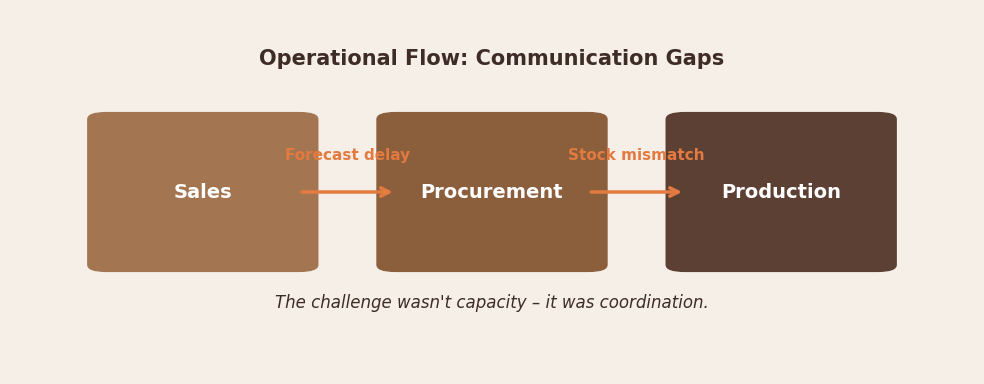

In [35]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# === 1️⃣ Coffee color palette ===
colors = {
    "sales": "#A47551",       # caramel brown
    "procurement": "#8B5E3C",  # medium roast
    "production": "#5C4033",   # espresso brown
    "bg": "#F5EFE7",           # beige background
    "text": "#3E2C26",         # dark brown text
    "arrow": "#E37B40"         # orange accent for data gap arrows
}

# === 2️⃣ Setup figure ===
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])
ax.axis("off")

# === 3️⃣ Box positions and sizes ===
boxes = [
    (0.1, 0.3, 0.2, 0.4, "Sales", colors["sales"]),
    (0.4, 0.3, 0.2, 0.4, "Procurement", colors["procurement"]),
    (0.7, 0.3, 0.2, 0.4, "Production", colors["production"])
]

# === 4️⃣ Draw boxes ===
for x, y, w, h, label, color in boxes:
    rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", ec="none", fc=color)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=14, color="white", weight="bold")

# === 5️⃣ Draw arrows with data gap labels ===
arrows = [
    (0.3, 0.5, 0.4, 0.5, "Forecast delay"),
    (0.6, 0.5, 0.7, 0.5, "Stock mismatch")
]

for x1, y1, x2, y2, label in arrows:
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="->", color=colors["arrow"], lw=2.5, mutation_scale=15)
    ax.add_patch(arrow)
    ax.text((x1 + x2)/2, y1 + 0.08, label, ha="center", va="bottom", fontsize=11, color=colors["arrow"], weight="bold")

# === 6️⃣ Title ===
ax.text(0.5, 0.85, "Operational Flow: Communication Gaps", ha="center", fontsize=15, color=colors["text"], weight="bold")
ax.text(0.5, 0.18, "The challenge wasn't capacity – it was coordination.", ha="center", fontsize=12, color=colors["text"], style="italic")

plt.tight_layout()
plt.show()

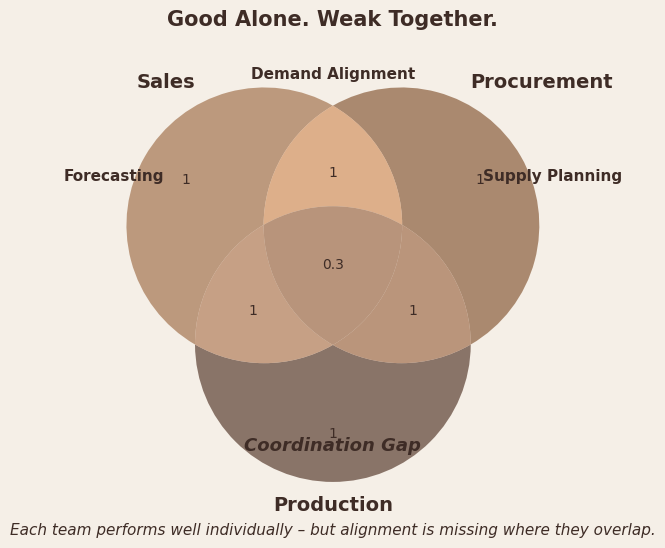

In [39]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# === 1️⃣ Coffee color palette ===
colors = {
    "sales": "#A47551",       # caramel brown
    "procurement": "#8B5E3C",  # medium roast
    "production": "#5C4033",   # espresso brown
    "bg": "#F5EFE7",           # beige background
    "text": "#3E2C26",         # dark brown text
}

# === 2️⃣ Setup figure ===
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(colors["bg"])
ax.set_facecolor(colors["bg"])

# === 3️⃣ Create improved Venn Diagram ===
venn = venn3(
    subsets=(1, 1, 1, 1, 1, 1, 0.3),
    set_labels=("Sales", "Procurement", "Production"),
    set_colors=(colors["sales"], colors["procurement"], colors["production"]),
    alpha=0.7
)

# === 4️⃣ Customize labels ===
for text in venn.set_labels:
    text.set_color(colors["text"])
    text.set_fontsize(14)
    text.set_weight("bold")

for text in venn.subset_labels:
    if text:
        text.set_color(colors["text"])
        text.set_fontsize(10)

# === 5️⃣ Add intersection meaning labels ===
ax.text(-0.65, 0.25, "Forecasting", ha="center", fontsize=11, color=colors["text"], weight="bold")  # Sales ∩ Procurement
ax.text(0.65, 0.25, "Supply Planning", ha="center", fontsize=11, color=colors["text"], weight="bold")  # Procurement ∩ Production
ax.text(0, 0.55, "Demand Alignment", ha="center", fontsize=11, color=colors["text"], weight="bold")  # Sales ∩ Production
ax.text(0, -0.55, "Coordination Gap", ha="center", fontsize=13, color=colors["text"], weight="bold", style="italic")  # Center gap

# === 6️⃣ Add storytelling title ===
ax.set_title("Good Alone. Weak Together.", fontsize=15, fontweight="bold", color=colors["text"], pad=20)
ax.text(0, -0.8, "Each team performs well individually – but alignment is missing where they overlap.",
        ha="center", fontsize=11, color=colors["text"], style="italic")

plt.show()

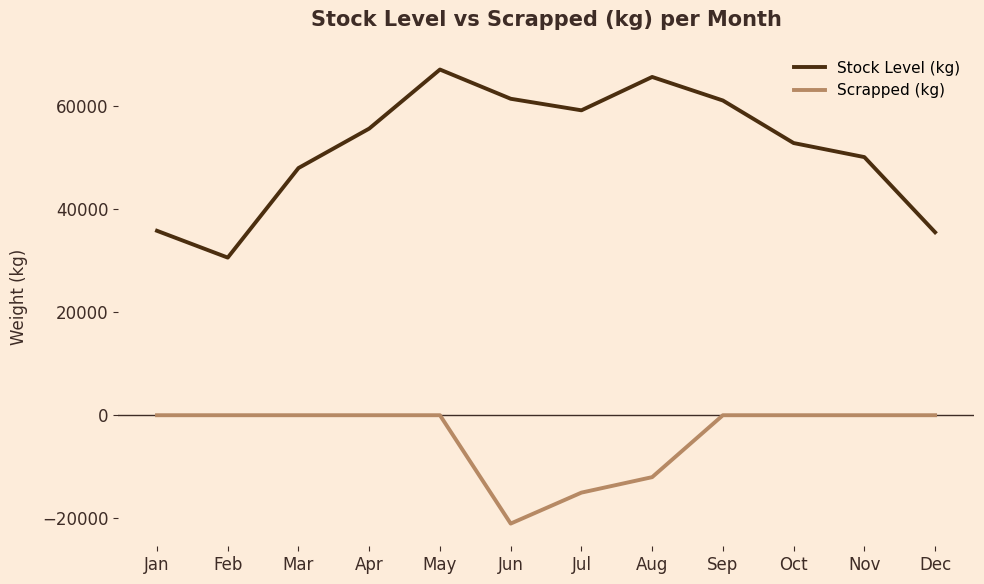

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1️⃣ Load data ===
file_path = "Bean there done that data.xlsx"
inv_fp = pd.read_excel(file_path, sheet_name="Inventory (finished product)")

# === 2️⃣ Clean and prepare ===
inv_fp.columns = inv_fp.columns.str.strip()
month_order = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}
inv_fp["Month_num"] = inv_fp["Month"].map(month_order)
inv_fp = inv_fp.sort_values("Month_num")

# === 3️⃣ Aggregate by month ===
monthly = inv_fp.groupby("Month", sort=False)[["Stock level", "Scrapped"]].sum().reset_index()

# === 4️⃣ Month abbreviations ===
month_abbr = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly["Month_abbr"] = month_abbr

# === 5️⃣ Coffee color palette ===
colors = {
    "bg": "#FDEcDA",         # new warm peach-beige background
    "stock": "#4B2E0F",      # espresso brown
    "scrap": "#B68964",      # latte brown
    "text": "#3E2C26"        # dark chocolate labels
}

# === 6️⃣ Apply clean minimalist style ===
plt.style.use("default")
plt.rcParams.update({
    "axes.facecolor": colors["bg"],
    "figure.facecolor": colors["bg"],
    "axes.edgecolor": "none",
    "axes.labelcolor": colors["text"],
    "xtick.color": colors["text"],
    "ytick.color": colors["text"],
    "font.family": "sans-serif",
    "font.size": 12
})

# === 7️⃣ Plot ===
fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(0, color=colors["text"], linewidth=1)

# Stock level (above)
ax.plot(monthly["Month_abbr"], monthly["Stock level"],
        color=colors["stock"], linewidth=2.8, label="Stock Level (kg)")

# Scrapped (below, already negative)
ax.plot(monthly["Month_abbr"], monthly["Scrapped"],
        color=colors["scrap"], linewidth=2.8, label="Scrapped (kg)")

# === 8️⃣ Style cleanup ===
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

ax.set_title("Stock Level vs Scrapped (kg) per Month",
             fontsize=15, fontweight="bold", color=colors["text"], pad=15)
ax.set_xlabel("")
ax.set_ylabel("Weight (kg)", fontsize=12, labelpad=10)
ax.legend(frameon=False, fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()


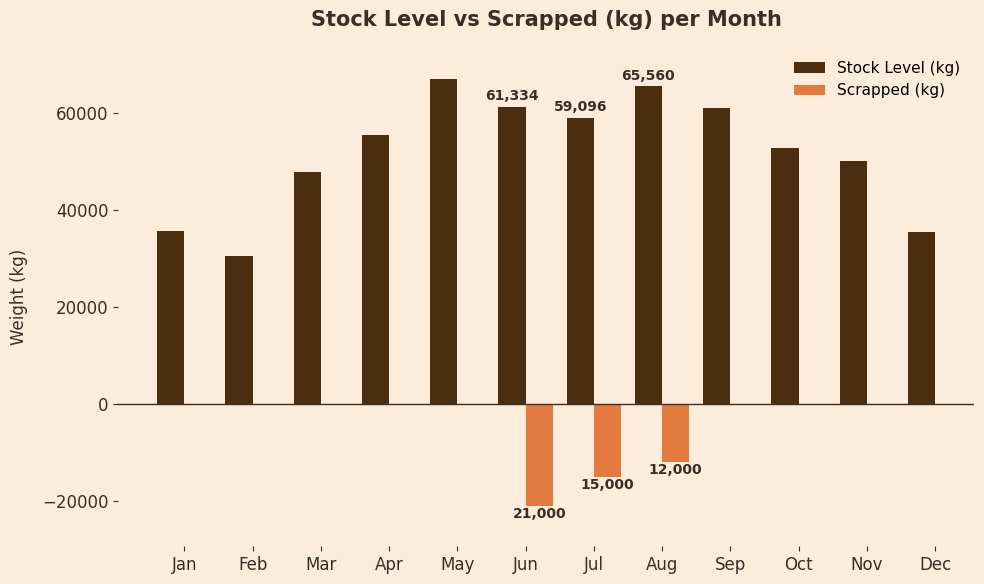

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# === Load & prep ===
file_path = "Bean there done that data.xlsx"
inv_fp = pd.read_excel(file_path, sheet_name="Inventory (finished product)")
inv_fp.columns = inv_fp.columns.str.strip()
month_order = {"January":1,"February":2,"March":3,"April":4,"May":5,"June":6,
               "July":7,"August":8,"September":9,"October":10,"November":11,"December":12}
inv_fp["Month_num"] = inv_fp["Month"].map(month_order)
inv_fp = inv_fp.sort_values("Month_num")

monthly = inv_fp.groupby("Month", sort=False)[["Stock level","Scrapped"]].sum().reset_index()
monthly["Month_abbr"] = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][:len(monthly)]

# === Coffee palette ===
colors = {
    "bg": "#FDEcDA",    # warm peach-beige
    "stock": "#4B2E0F", # espresso brown
    "scrap": "#E37B40", # caramel orange (scrap highlight)
    "text": "#3E2C26"   # dark chocolate
}

plt.style.use("default")
plt.rcParams.update({
    "axes.facecolor": colors["bg"], "figure.facecolor": colors["bg"],
    "axes.edgecolor": "none", "axes.labelcolor": colors["text"],
    "xtick.color": colors["text"], "ytick.color": colors["text"],
    "font.family": "sans-serif", "font.size": 12
})

fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(0, color=colors["text"], linewidth=1)

bar_w = 0.4
x = range(len(monthly))
scrapped_months = monthly.index[monthly["Scrapped"] != 0].tolist()

# Stock bars (handle captured for legend)
stock_bars = ax.bar([i - bar_w/2 for i in x],
                    monthly["Stock level"], width=bar_w, color=colors["stock"])

# Scrapped bars (draw only where non-zero; create a proxy patch for legend)
for i in scrapped_months:
    ax.bar(i + bar_w/2, monthly["Scrapped"][i], width=bar_w, color=colors["scrap"])
scrap_proxy = Patch(facecolor=colors["scrap"])

# Value labels (only for scrap months)
for i in scrapped_months:
    # stock label above
    ax.text(i - bar_w/2,
            monthly["Stock level"][i] + (monthly["Stock level"].max() * 0.02),
            f"{monthly['Stock level'][i]:,.0f}",
            ha="center", color=colors["text"], fontsize=10, fontweight="bold")
    # scrap label below (with padding)
    ax.text(i + bar_w/2,
            monthly["Scrapped"][i] - (abs(monthly["Scrapped"].min()) * 0.12),
            f"{abs(monthly['Scrapped'][i]):,.0f}",
            ha="center", color=colors["text"], fontsize=10, fontweight="bold")

# Extend y-limits so scrap labels never cross x-axis
ymin = monthly["Scrapped"].min() * 1.4
ymax = monthly["Stock level"].max() * 1.1
ax.set_ylim(ymin, ymax)

# Clean style + axes
ax.set_xticks(list(x))
ax.set_xticklabels(monthly["Month_abbr"])
for s in ax.spines.values():
    s.set_visible(False)
ax.grid(False)

ax.set_title("Stock Level vs Scrapped (kg) per Month",
             fontsize=15, fontweight="bold", color=colors["text"], pad=15)
ax.set_xlabel("")
ax.set_ylabel("Weight (kg)", fontsize=12, labelpad=10)

# ✅ Legend now matches bar colors
ax.legend([stock_bars, scrap_proxy], ["Stock Level (kg)", "Scrapped (kg)"],
          frameon=False, fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()
